In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

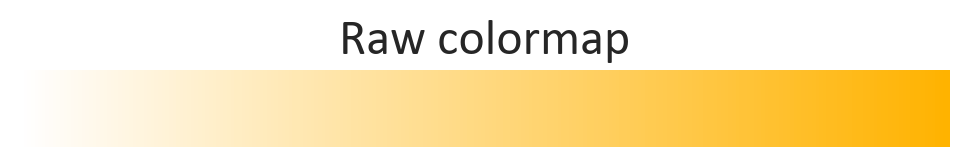

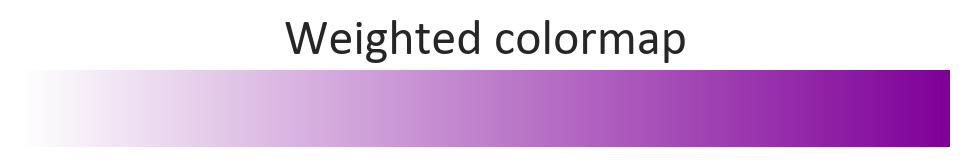

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = "/home/groot/.fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, transparent=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=transparent, **savefig_kwargs)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
# DATA_DIR = Path("/media/storage/phd/neuroaging/data")
DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")

# Output directory for figures
# OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig2_clustering")
OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig2_clustering")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
metrics = ["adc", "gm_vol"]
distribution_metric = "qfmean"

bad_subjects = ["IN120120"]

all_data = {}
for metric in metrics:
    data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    data = data[~data["subject_code"].isin(bad_subjects)]

    data["age_squared"] = data["age_at_scan"] ** 2
    data["sex"] = data["sex"].map({"M": 0, "F": 1})
    all_data[metric] = data

/tmp/ipykernel_3009598/1888622274.py:8: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
/tmp/ipykernel_3009598/1888622274.py:8: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [5]:
metric_col = "volume" if metric == "gm_vol" else distribution_metric

In [6]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [7]:
def assign_weights_by_population(
    data: pd.DataFrame,
    population_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    range_start: str = "range_start",
    range_end: str = "range_end",
    total: str = "total",
) -> np.ndarray:
    """
    Post-stratification weights so the age distribution of *data*
    matches an external reference.

    - Accepts integer or float ages.
    - Handles boundary ages (include_lowest=True).
    - Leaves bins with zero sample untouched (weight=0 → later dropped).
    - Returns weights whose mean == 1 across *non-zero* weights.
    """

    # 1. Make sure population bins are well-formed
    pop = (
        population_df[[range_start, range_end, total]]
        .sort_values(range_start)
        .reset_index(drop=True)
    )
    if (pop[range_end] <= pop[range_start]).any():
        raise ValueError("Each range_end must exceed range_start.")
    if (pop[range_start].iloc[1:].values < pop[range_end].iloc[:-1].values).any():
        raise ValueError("Age bins overlap or are not strictly increasing.")

    # 2. Bin edges for pd.cut  →  [..., last_end]  (right-inclusive)
    bin_edges = pop[range_start].tolist() + [pop[range_end].iloc[-1]]

    # Population proportions (works for % or counts)
    pop_prop = pop[total] / pop[total].sum()

    # 3. Assign each participant to a bin
    sample_bins = pd.cut(
        data[age_col],
        bins=bin_edges,
        right=True,  # include right edge
        include_lowest=True,  # include first left edge
        labels=pop.index,  # integer labels 0..n-1
    )

    # 4. Sample distribution
    sample_counts = sample_bins.value_counts(sort=False)
    sample_prop = sample_counts / sample_counts.sum()

    # 5. Weight lookup  (population / sample)  — careful with zeros
    weight_lookup = pop_prop / sample_prop.replace(0, np.nan)

    # 6. Map to rows; bins with zero sample → NaN weight → drop later
    w = sample_bins.map(weight_lookup).to_numpy()

    # Assign *zero* weight (instead of 1) to rows that were NaN
    w = np.where(np.isnan(w), 0.0, w)

    # 7. Rescale so mean(weight > 0) == 1
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    return w

In [8]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [9]:
import numpy as np
import pandas as pd

def compute_joint_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    sex_col: str = "sex",
    male_label = 0,
    female_label = 1,
    start_col: str = "range_start",
    end_col: str = "range_end",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Computes joint post-stratification weights for Age and Sex so the sample
    matches an external census distribution.
    
    Parameters
    ----------
    sample_df : DataFrame with age and sex columns.
    pop_df    : DataFrame with [range_start, range_end, male, female].
    male_label/female_label : The values used in sample_df['sex'] (e.g., 0 and 1).
    cap       : Optional multiplier to truncate extreme weights.
    """
    # 1. Validation: Ensure all columns exist
    required_sample = [age_col, sex_col]
    required_pop = [start_col, end_col, "male", "female"]
    
    for col in required_sample:
        if col not in sample_df.columns:
            raise KeyError(f"Column '{col}' not found in sample_df. Available: {list(sample_df.columns)}")
    for col in required_pop:
        if col not in pop_df.columns:
            raise KeyError(f"Column '{col}' not found in pop_df. Available: {list(pop_df.columns)}")

    # 2. Tidy population table and convert to Long Format
    pop = pop_df.sort_values(start_col).copy()
    pop_long = pop.melt(
        id_vars=[start_col, end_col],
        value_vars=['male', 'female'],
        var_name='sex_str',
        value_name='pop_val'
    )
    
    # Map 'male'/'female' strings to the labels in your sample (0 and 1)
    pop_long[sex_col] = pop_long['sex_str'].map({'male': male_label, 'female': female_label})
    pop_long['prop_pop'] = pop_long['pop_val'] / pop_long['pop_val'].sum()
    
    # 3. Create Age Bins
    # edges define brackets: [0, 5, 10, ..., 90, 1000001]
    edges = sorted(list(pop[start_col].unique()) + [int(pop[end_col].max()) + 1])
    bin_labels = sorted(list(pop[start_col].unique()))
    
    sample = sample_df.copy()
    sample['age_bin_start'] = pd.cut(
        sample[age_col], 
        bins=edges, 
        labels=bin_labels, 
        right=False # standard for age: [start, end)
    )
    
    if sample['age_bin_start'].isna().any():
        print("Warning: Some participants fall outside the census age ranges.")

    # 4. Calculate Sample Proportions per (Age, Sex) cell
    sample_counts = sample.groupby(['age_bin_start', sex_col], observed=False).size().reset_index(name='n_sample')
    sample_counts['prop_sample'] = sample_counts['n_sample'] / sample_counts['n_sample'].sum()
    
    # Ensure types match for merging
    sample_counts['age_bin_start'] = sample_counts['age_bin_start'].astype(pop_long[start_col].dtype)
    
    # 5. Calculate Weight Factors (Population Proportion / Sample Proportion)
    weights_lookup = pd.merge(
        pop_long[[start_col, sex_col, 'prop_pop']],
        sample_counts,
        left_on=[start_col, sex_col],
        right_on=['age_bin_start', sex_col],
        how='left'
    )
    weights_lookup['weight_factor'] = weights_lookup['prop_pop'] / weights_lookup['prop_sample'].replace(0, np.nan)
    
    # 6. Map Weights back to individual sample rows
    sample['age_bin_start'] = sample['age_bin_start'].astype(pop_long[start_col].dtype)
    sample_with_weights = pd.merge(
        sample,
        weights_lookup[[start_col, sex_col, 'weight_factor']],
        left_on=['age_bin_start', sex_col],
        right_on=[start_col, sex_col],
        how='left'
    )
    
    w = sample_with_weights['weight_factor'].fillna(0).to_numpy()
    
    # 7. Apply optional cap and Rescale so mean weight = 1
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean() if any(w > 0) else 1.0
        w = np.clip(w, 0, cap * mean_pos)
        
    if any(w > 0):
        w = w / w.mean()
    else:
        print("Error: No matches found between sample and census. Weights are all zero.")

    if return_bin_table:
        return w, weights_lookup

    

    return w

In [10]:
# assign weights
for _, data in all_data.items():
    data["weight"], _ = compute_joint_poststrat_weights(
        data,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )

In [11]:
from statsmodels.formula.api import ols, wls
import statsmodels.formula.api as smf


def regional_models(region_data: pd.DataFrame, metric_col: str, model: str, covariates: list):
    """
    Fit a linear model to the data for each region.
    """
    # Fit the model
    if model == "ols":
        model = ols(f"{metric_col} ~ {' + '.join(covariates)}", data=region_data)
    elif model == "wls":
        model = wls(
            f"{metric_col} ~ {' + '.join(covariates)}",
            data=region_data,
            weights=region_data["weight"],
        )
    else:
        raise ValueError("Model must be either 'ols' or 'wls'.")

    # Fit the model
    results = model.fit()

    # Return the results
    return results

In [12]:
# from tqdm import tqdm

# # Set up dataframes to store results
# lin_unw, lin_w, quad_unw, quad_w = parcels.copy(), parcels.copy(), parcels.copy(), parcels.copy()

# covariates = ["age_at_scan", "sex"]
# if metric == "gm_vol":
#     covariates += ["tiv"]

# for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
#     region_data = data[data[region_col] == row[region_col]].copy()
#     region_data.rename(columns={metric_col: "value"}, inplace=True)
#     for results_df, model, is_quadratic in zip(
#         [lin_unw, lin_w, quad_unw, quad_w],
#         ["ols", "wls", "ols", "wls"],
#         [False, False, True, True],
#     ):
#         # Fit the model
#         if is_quadratic:
#             region_data["age_squared"] = region_data["age_at_scan"] ** 2
#             results = regional_models(region_data, "value", model, covariates + ["age_squared"])
#         else:
#             results = regional_models(region_data, "value", model, covariates)

#         # Store the results
#         results_df.loc[i, "model"] = results
#         results_df.loc[i, "pvalue"] = results.f_pvalue
#         results_df.loc[i, "r2"] = results.rsquared
#         results_df.loc[i, "r2_adj"] = results.rsquared_adj
#         results_df.loc[i, "n"] = len(region_data)
#         # if i == 405 and model == "wls" and is_quadratic:
#         #     a = results

In [13]:
# Tell the pipeline which side of the parabola is "structural stabilisation"
orientation = {  # feel free to expand
    "gm_vol": "max",  # concave-down expected
    "adc": "min",  # concave-up expected
    # "fa"   : "min",
    # "rd"   : "min",
}


def vertex_age(beta1, beta2):
    # Age at vertex of a quadratic beta0 + beta1*x + beta2*x^2.
    return -beta1 / (2 * beta2)


def stabilization_age(metric, betas, mean_age, *, age_min=18, age_max=75):
    b1, b2 = betas["age"], betas["age_sq"]
    
    # 1. Determine if the shape is 'biologically expected'
    is_u_shaped = b2 > 0
    if "vol" in metric:
        valid_shape = not is_u_shaped  # Expect Inverted-U (beta2 < 0)
    else:
        valid_shape = is_u_shaped      # Expect U-shape (beta2 > 0)

    if not valid_shape:
        # Return age_min as a default 'clipped' value instead of NaN 
        # to prevent downstream plotting/analysis errors
        return age_min, True, is_u_shaped

    # 2. Compute vertex (Corrected: add the mean_age shift)
    v_centered = -b1 / (2 * b2)
    age_star = mean_age + v_centered
    
    # 3. Clip and flag
    clipped = False
    if age_star < age_min:
        age_star, clipped = age_min, True
    elif age_star > age_max:
        age_star, clipped = age_max, True
        
    return age_star, clipped, is_u_shaped



In [14]:
from tqdm import tqdm


regional_results = {}
mean_age_by_metric = {metric: data["age_at_scan"].mean() for metric, data in all_data.items()}

for metric, data in all_data.items():
    metric_col = "volume" if metric == "gm_vol" else distribution_metric
    # Set up dataframes to store results
    quad_w, lin_w = parcels.copy(), parcels.copy()

    mean_age = mean_age_by_metric[metric]

    covariates = ["age_c", "C(sex)"]
    if metric == "gm_vol":
        covariates += ["tiv"]

    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        region_data = data[data[region_col] == row[region_col]].copy()
        region_data.rename(columns={metric_col: "value"}, inplace=True)
        region_data["age_c"] = region_data["age_at_scan"] - mean_age
        # region_data["age_c"] = region_data["age_at_scan"]
        region_data["age_c2"] = region_data["age_c"] ** 2

        lin_model = smf.wls(
            "value ~ " + " + ".join(covariates),
            data=region_data,
            weights=region_data["weight"],
        ).fit()
        quad_model = smf.wls(
            "value ~ " + " + ".join(covariates) + " + age_c2",
            data=region_data,
            weights=region_data["weight"],
        ).fit()

        f, p, _ = quad_model.compare_f_test(lin_model)
        delta_aic = quad_model.aic - lin_model.aic
        for results_df, model, is_quadratic in zip(
            [lin_w, quad_w],
            [lin_model, quad_model],
            [False, True],
        ):
            # Store the results
            results_df.loc[i, "model"] = model
            results_df.loc[i, "aic"] = model.aic
            results_df.loc[i, "pvalue"] = model.f_pvalue
            results_df.loc[i, "r2"] = model.rsquared
            results_df.loc[i, "r2_adj"] = model.rsquared_adj
            results_df.loc[i, "n"] = len(region_data)
            results_df.loc[i, "intercept"] = model.params["Intercept"]
            results_df.loc[i, "t_intercept"] = model.tvalues["Intercept"]
            results_df.loc[i, "pvalue_intercept"] = model.pvalues["Intercept"]
            results_df.loc[i, "beta1"] = model.params["age_c"]
            results_df.loc[i, "se_beta1"] = model.bse["age_c"]
            results_df.loc[i, "t_beta1"] = model.tvalues["age_c"]
            results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_c"]

            if is_quadratic:
                results_df.loc[i, "beta2"] = model.params["age_c2"]
                results_df.loc[i, "se_beta2"] = model.bse["age_c2"]
                results_df.loc[i, "t_beta2"] = model.tvalues["age_c2"]
                results_df.loc[i, "pvalue_beta2"] = model.pvalues["age_c2"]
                beta1, beta2 = (
                    model.params["age_c"],
                    model.params["age_c2"],
                )
                if delta_aic < -15:
                    # We only attempt to find a vertex if the quadratic is significantly better
                    age_star, clipped, u = stabilization_age(
                        metric,
                        {"age": quad_model.params["age_c"], "age_sq": quad_model.params["age_c2"]},
                        mean_age
                    )
                else:
                    # For linear or non-sig models, we default to the start of the lifespan
                    age_star, clipped, u = 18, True, (quad_model.params["age_c2"] > 0)
                results_df.loc[i, "age_star"] = age_star
                results_df.loc[i, "clipped"] = clipped
            else:
                results_df.loc[i, "beta2"] = 0
                results_df.loc[i, "se_beta2"] = 0
                results_df.loc[i, "t_beta2"] = 0
                results_df.loc[i, "pvalue_beta2"] = 1
                results_df.loc[i, "age_star"] = 18
                results_df.loc[i, "clipped"] = True

    regional_results[metric] = {
        "lin_w": lin_w,
        "quad_w": quad_w,
    }


Fitting models:   0%|          | 0/454 [00:00<?, ?it/s]

Fitting models: 100%|██████████| 454/454 [00:24<00:00, 18.57it/s]


In [15]:
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

for metric, results in regional_results.items():
    w_compare = parcels.copy()

    # do f test to compare between quadratic and linear models
    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        # collect models
        model1 = results["lin_w"].loc[i, "model"]
        model2 = results["quad_w"].loc[i, "model"]
        f, p, _ = model2.compare_f_test(model1)
        w_compare.loc[i, "f"] = f
        w_compare.loc[i, "pvalue"] = p
        w_compare.loc[i, "n"] = model1.nobs
        w_compare.loc[i, "AIC(lin)"] = model1.aic
        w_compare.loc[i, "AIC(quad)"] = model2.aic
        w_compare.loc[i, "delta_AIC"] = model2.aic - model1.aic
        w_compare["log(f)"] = np.log(w_compare["f"])
    # Save the comparison results
    w_compare["p_corrected"] = multipletests(w_compare["pvalue"], method="fdr_bh")[
        1
    ]  # Benjamini-Hochberg correction
    regional_results[metric]["w_compare"] = w_compare
    # do f test to compare between quadratic and linear models
    # model1 = lin_unw.loc[i, "model"]
    # model2 = quad_unw.loc[i, "model"]
    # f, p, _ = model2.compare_f_test(model1)
    # unw_compare.loc[i, "f"] = f
    # unw_compare.loc[i, "pvalue"] = p
    # unw_compare.loc[i, "n"] = model1.nobs
    # weighted

Fitting models: 100%|██████████| 454/454 [00:00<00:00, 1212.16it/s]


In [16]:
# Feature + weighting configuration
feature_mode = "coeff"  # trajectory+coeff | trajectory | trajectory+coeff
age_grid = np.linspace(20, 80, 9)  # ages used for trajectory features

features_df = parcels.copy()
coeff_features = []
traj_features = []

for metric in metrics:
    lin = regional_results[metric]["lin_w"]
    quad = regional_results[metric]["quad_w"]
    compare = regional_results[metric]["w_compare"]
    mean_age = mean_age_by_metric[metric]

    best = pd.DataFrame(index=parcels.index)

    for i in parcels.index:
        delta_aic = compare.loc[i, "delta_AIC"]
        p_value = compare.loc[i, "pvalue"]
        use_quad = (delta_aic < -15) and (p_value < (0.05 / len(parcels)))
        if use_quad:
            src = quad.loc[i]
            best.loc[i, "model"] = "quad"
            best.loc[i, "intercept"] = src["intercept"]
            best.loc[i, "beta1"] = src["beta1"]
            best.loc[i, "beta2"] = src["beta2"]
            best.loc[i, "r2_adj"] = src["r2_adj"]
            best.loc[i, "se_beta1"] = src.get("se_beta1", np.nan)
            best.loc[i, "se_beta2"] = src.get("se_beta2", np.nan)
            best.loc[i, "age_star"] = src.get("age_star", 18)
        else:
            src = lin.loc[i]
            best.loc[i, "model"] = "lin"
            best.loc[i, "intercept"] = src["intercept"]
            best.loc[i, "beta1"] = src["beta1"]
            best.loc[i, "beta2"] = 0
            best.loc[i, "r2_adj"] = src["r2_adj"]
            best.loc[i, "se_beta1"] = src.get("se_beta1", np.nan)
            best.loc[i, "se_beta2"] = 0
            best.loc[i, "age_star"] = 18

    regional_results[metric]["best_w"] = best

    # Coefficient features (centered age -> intercept is value at mean age)
    for feature in ["beta1", "beta2", "age_star"]:
    # for feature in ["beta1", "beta2", "age_star"]:
        feat_name = f"{metric}_{feature}"
        features_df[feat_name] = best[feature]
        coeff_features.append(feat_name)

    # Trajectory features
    for age in age_grid:
        age_c = age - mean_age
        feat_name = f"{metric}_pred_{int(age)}"
        features_df[feat_name] = (
            best["intercept"] + best["beta1"] * age_c + best["beta2"] * (age_c ** 2)
        )
        traj_features.append(feat_name)

# Reliability weights (combine fit quality + coefficient uncertainty)
eps = 1e-6
weights = []
for i in parcels.index:
    metric_weights = []
    for metric in metrics:
        best = regional_results[metric]["best_w"]
        r2 = max(best.loc[i, "r2_adj"], 0)
        se_beta1 = best.loc[i, "se_beta1"]
        se_beta2 = best.loc[i, "se_beta2"]
        if not np.isfinite(se_beta1):
            se_beta1 = 0.0
        if not np.isfinite(se_beta2):
            se_beta2 = 0.0
        conf = 1.0 / (se_beta1 + se_beta2 + eps)
        metric_weights.append(r2 * conf)
    weights.append(np.mean(metric_weights))

weights = np.asarray(weights, dtype=float)
lo, hi = np.nanpercentile(weights, [5, 95])
weights = np.clip(weights, lo, hi)
weights = np.clip(weights, 1e-6, None)
weights = weights / np.sum(weights)

# Choose features for clustering
if feature_mode == "coeff":
    features = coeff_features
elif feature_mode == "trajectory":
    features = traj_features
elif feature_mode == "trajectory+coeff":
    features = traj_features + coeff_features
else:
    raise ValueError(f"Unknown feature_mode: {feature_mode}")


### Clustering overview (Fig 2)

- Fit per-region WLS models with centered age (linear + quadratic) for each metric.
- Use AIC model-averaging to get smooth coefficient estimates per region.
- Build features from coefficients and/or predicted trajectories on an age grid.
- Compute per-region reliability weights from adjusted R^2 and coefficient SEs.
- Standardize features and fit weighted GMMs across K; evaluate AIC/BIC + stability.
- Assign clusters, reorder by size, and map centroids/probabilities to surfaces.


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture  # Changed from sklearn.cluster.KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score

print(f"Features selected for clustering: {features}")

k_range = range(2, 20)  # GMM clusters from 2 to 19

X = features_df[features].astype(float)
X = X.replace([np.inf, -np.inf], np.nan)
valid_mask = np.isfinite(X).all(axis=1)
if not valid_mask.all():
    print(f"Dropping {np.sum(~valid_mask)} regions with non-finite features")
    X = X.loc[valid_mask]

weights_series = pd.Series(weights, index=features_df.index).loc[X.index]
weights_series = weights_series / weights_series.sum()


Features selected for clustering: ['adc_beta1', 'adc_beta2', 'adc_age_star', 'gm_vol_beta1', 'gm_vol_beta2', 'gm_vol_age_star']


In [18]:
import numpy as np
from sklearn.mixture import GaussianMixture

# Assume these are defined from earlier:
# X = coef_matrix_std  # Your standardized coefficient matrix (n_regions x 6)
# weights = ...  # Your computed weights (array of length n_regions, e.g., average R²)

# Normalize weights to probabilities (must sum to 1)
probs = weights / np.sum(weights)

# Number of regions (inferred from X)
n_regions = len(X)  # Or use len(parcels) if that's your variable

# Resample indices with replacement, proportional to probs
n_resamples = n_regions * 10  # e.g., 10x oversampling; adjust as needed
sampled_indices = np.random.choice(n_regions, size=n_resamples, replace=True, p=probs)

In [19]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.mixture._gaussian_mixture import _compute_precision_cholesky

class WeightedGaussianMixture(GaussianMixture):
    def fit(self, X, y=None, sample_weight=None):
        # We store weights to use them during the EM iterations
        self.sample_weight = sample_weight
        return super().fit(X, y)

    def _m_step(self, X, log_resp):
        """Modified M-step to include sample weights with regularization."""
        n_samples, _ = X.shape
        resp = np.exp(log_resp)
        
        # 1. Apply weights to responsibilities
        if self.sample_weight is not None:
            # Normalize weights to sum to n_samples for numerical stability
            sw = self.sample_weight * (n_samples / np.sum(self.sample_weight))
            w_resp = resp * sw[:, np.newaxis]
        else:
            w_resp = resp

        # 2. Update Weights (Mixing Coefficients)
        nk = w_resp.sum(axis=0) + 10 * np.finfo(resp.dtype).eps
        self.weights_ = nk / n_samples
        
        # 3. Update Means
        self.means_ = np.dot(w_resp.T, X) / nk[:, np.newaxis]
        
        # 4. Update Covariances with Regularization
        self.covariances_ = self._estimate_weighted_covariances(
            X, w_resp, nk, self.means_, self.covariance_type
        )
        
        # Add regularization to the diagonal to prevent "ill-defined" error
        if self.covariance_type == 'full':
            for k in range(self.n_components):
                self.covariances_[k].flat[::X.shape[1] + 1] += self.reg_covar
        elif self.covariance_type == 'diag':
            self.covariances_ += self.reg_covar

        # 5. Precompute Cholesky for the next E-step
        self.precisions_cholesky_ = _compute_precision_cholesky(
            self.covariances_, self.covariance_type
        )

    def _estimate_weighted_covariances(self, X, w_resp, nk, means, covariance_type):
        if covariance_type == 'full':
            n_components, n_features = means.shape
            covariances = np.empty((n_components, n_features, n_features))
            for k in range(n_components):
                diff = X - means[k]
                # Weighted outer product
                covariances[k] = np.dot(w_resp[:, k] * diff.T, diff) / nk[k]
            return covariances
            
        elif covariance_type == 'diag':
            n_components, n_features = means.shape
            covariances = np.empty((n_components, n_features))
            for k in range(n_components):
                diff = X - means[k]
                # Weighted variance per feature
                covariances[k] = np.dot(w_resp[:, k], diff**2) / nk[k]
            return covariances
            
        raise NotImplementedError(f"Covariance type {covariance_type} not implemented.")

In [20]:
use_weights = False
compute_stability = False
n_boot = 100
bootstrap_frac = 1.0

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)


In [21]:

clustering_results = pd.DataFrame(
    index=k_range,
    columns=["aic", "bic", "silhouette", "stability_mean", "stability_std", "n_clusters"],
)

rng = np.random.default_rng(0)

for k in tqdm(k_range, desc="Fitting GMM", unit="clusters"):
    gmm = WeightedGaussianMixture(
        n_components=k,
        random_state=0,
        n_init=1000,
        max_iter=1000,
        init_params="random",
        reg_covar=1e-4,
        covariance_type="full",  # Use full covariance for GMM
    )

    # Fit the model
    gmm.fit(X_scaled_df, sample_weight=weights_series.values if use_weights else None)

    # Get the AIC and BIC
    aic = gmm.aic(X_scaled_df)
    bic = gmm.bic(X_scaled_df)

    # Get the cluster labels
    labels = gmm.predict(X_scaled_df)

    # Silhouette (unweighted)
    sil = silhouette_score(X_scaled_df, labels) if k > 1 else np.nan

    # Stability via bootstrap ARI
    stability_mean = np.nan
    stability_std = np.nan
    if compute_stability:
        boot_aris = []
        probs = weights_series.values / weights_series.values.sum()
        n_regions = len(X_scaled_df)
        n_boot_samples = int(n_regions * bootstrap_frac)
        for b in range(n_boot):
            boot_idx = rng.choice(n_regions, size=n_boot_samples, replace=True, p=probs)
            X_boot = X_scaled_df.iloc[boot_idx]
            w_boot = weights_series.values[boot_idx] if use_weights else None
            gmm_boot = WeightedGaussianMixture(
                n_components=k,
                random_state=b,
                n_init=20,
                max_iter=500,
                covariance_type="full",
            )
            gmm_boot.fit(X_boot, sample_weight=w_boot)
            labels_boot = gmm_boot.predict(X_scaled_df)
            boot_aris.append(adjusted_rand_score(labels, labels_boot))
        stability_mean = float(np.mean(boot_aris))
        stability_std = float(np.std(boot_aris))

    # Store results
    clustering_results.loc[k, "aic"] = aic
    clustering_results.loc[k, "bic"] = bic
    clustering_results.loc[k, "silhouette"] = sil
    clustering_results.loc[k, "stability_mean"] = stability_mean
    clustering_results.loc[k, "stability_std"] = stability_std
    clustering_results.loc[k, "n_clusters"] = k
    clustering_results.loc[k, "model"] = gmm


Fitting GMM: 100%|██████████| 18/18 [08:38<00:00, 28.82s/clusters]


In [22]:
# !pip install kneed
from kneed import KneeLocator

# Find the elbow/knee
# S=1.0 is the sensitivity; curve='convex' because BIC decreases then levels
kn = KneeLocator(k_range, clustering_results["bic"].astype(float), curve='convex', direction='decreasing', S=1)

print(f"The optimal K is: {kn.knee}")

# # Plotting to verify
# kn.plot_knee()

The optimal K is: 5


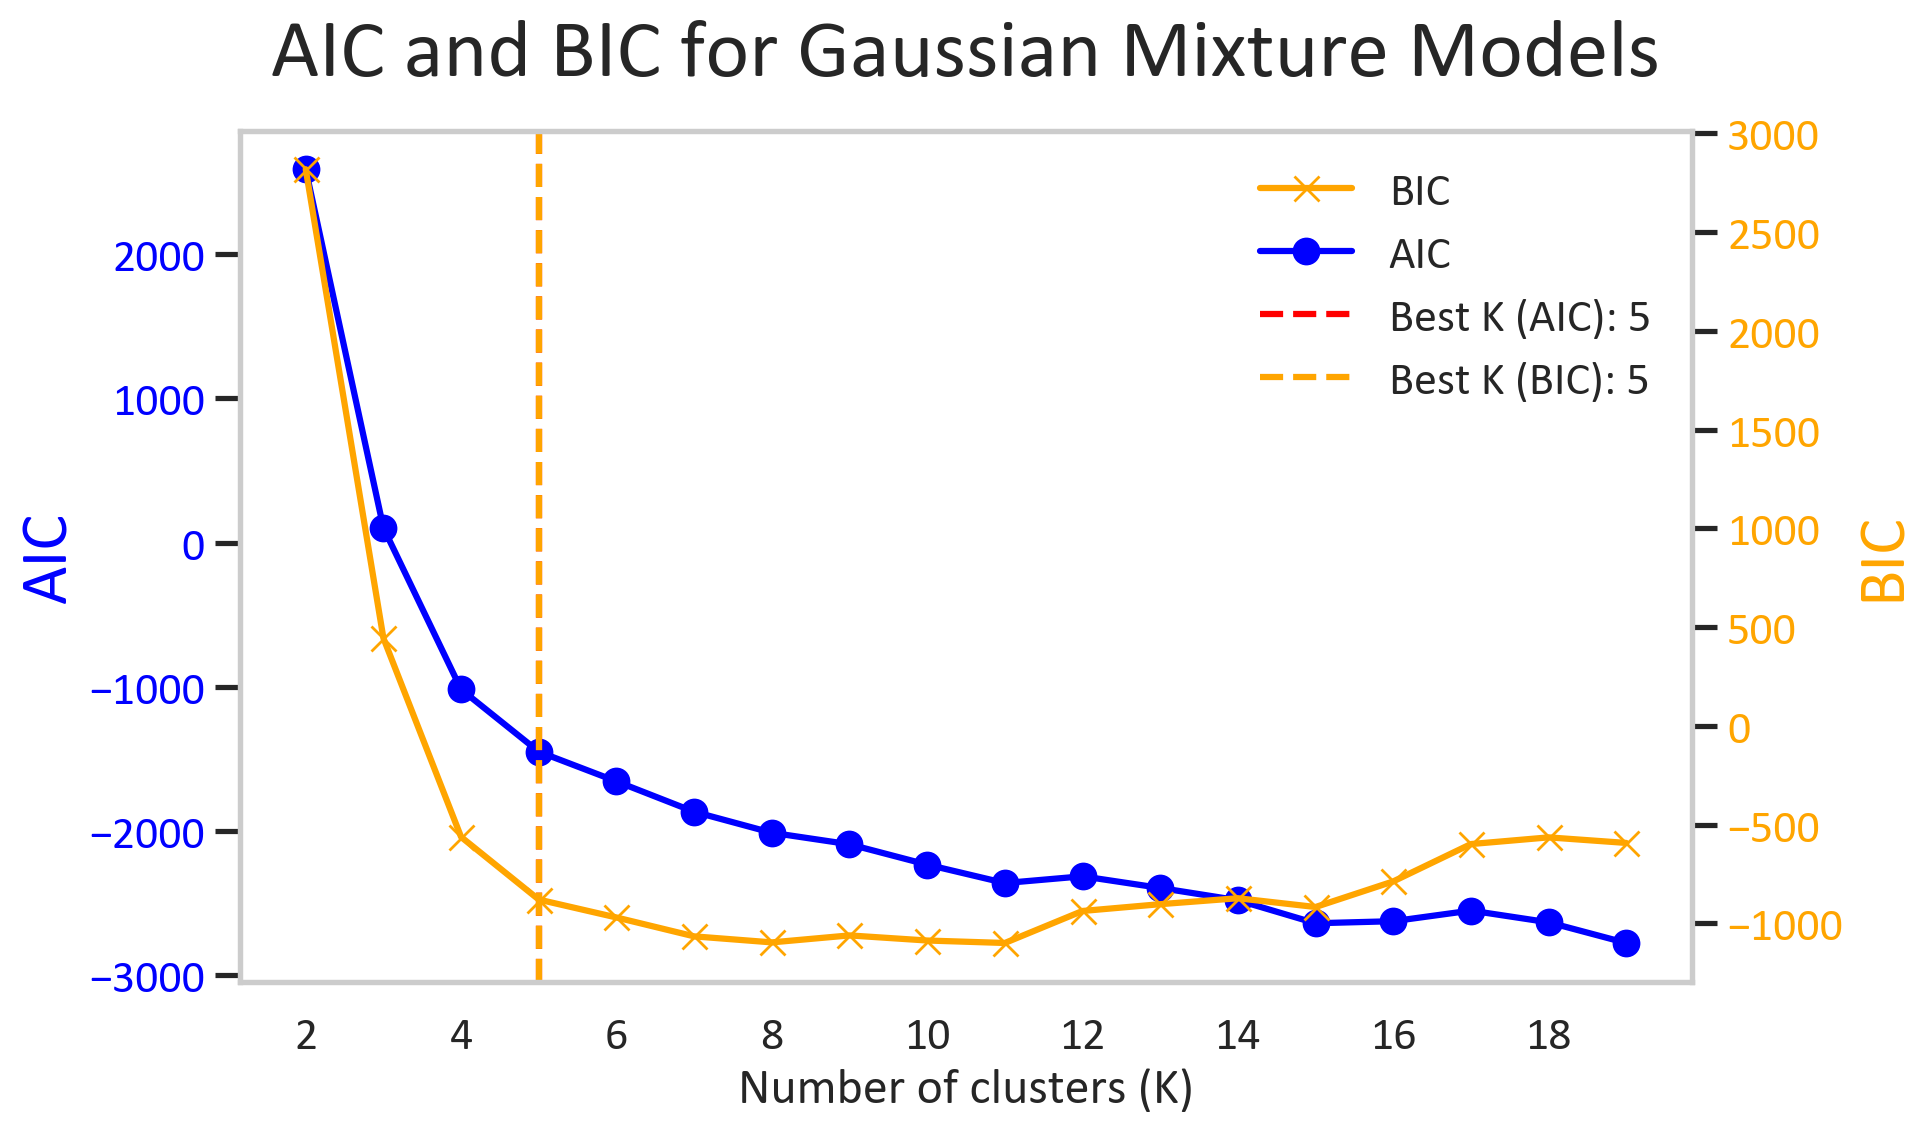

In [23]:
# plot the aic and bic
best_k_aic = KneeLocator(k_range, clustering_results["aic"].astype(float), curve='convex', direction='decreasing', S=1).knee
best_k_bic = KneeLocator(k_range, clustering_results["bic"].astype(float), curve='convex', direction='decreasing', S=1).knee
best_k_sil = clustering_results["silhouette"].astype(float).idxmax()
if clustering_results["stability_mean"].notna().any():
    best_k_stable = clustering_results["stability_mean"].astype(float).idxmax()
else:
    best_k_stable = None
# best_k_aic = clustering_results["aic"].astype(float).idxmin()
# best_k_sil = clustering_results["silhouette"].astype(float).idxmax()
# if clustering_results["stability_mean"].notna().any():
#     best_k_stable = clustering_results["stability_mean"].astype(float).idxmax()
# else:
#     best_k_stable = best_k_aic

best_k = best_k_aic
# best_k = kn.knee

fig, ax1 = plt.subplots(figsize=(10, 6))
# ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(
    clustering_results.index, clustering_results["aic"], label="AIC", color="blue", marker="o"
)
ax2.plot(
    clustering_results.index, clustering_results["bic"], label="BIC", color="orange", marker="x"
)

ax1.axvline(best_k_aic, color="red", linestyle="--", label=f"Best K (AIC): {best_k_aic}")
ax1.axvline(best_k_bic, color="orange", linestyle="--", label=f"Best K (BIC): {best_k_bic}")
# ax1.axvline(best_k_sil, color="green", linestyle=":", label=f"Best K (sil): {best_k_sil}")
if best_k_stable is not None:
    ax1.axvline(best_k_stable, color="purple", linestyle="-.", label=f"Best K (stability): {best_k_stable}")

# set the x ticks to integers (show every 2)
ax1.set_xticks(clustering_results.index[::2])
ax1.set_xticklabels(clustering_results.index[::2].astype(int))

ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("AIC", color="blue", fontsize=24)
ax2.set_ylabel("BIC", color="orange", fontsize=24)
ax1.tick_params(axis="y", labelcolor="blue")
ax2.tick_params(axis="y", labelcolor="orange")
ax1.set_title("AIC and BIC for Gaussian Mixture Models", fontsize=30, pad=20)

# combine the legends into one
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right", frameon=False)

# ax_sil = axes[1]
# ax_sil.plot(
#     clustering_results.index, clustering_results["silhouette"], label="Silhouette Score", color="green", marker="o"
# )
# ax_sil.axvline(best_k_sil, color="red", linestyle="--", label=f"Best K (sil): {best_k_sil}")
# ax_sil.set_xticks(clustering_results.index[::2])
# ax_sil.set_xticklabels(clustering_results.index[::2].astype(int))
# ax_sil.set_xlabel("Number of clusters (K)")
# ax_sil.set_ylabel("Silhouette Score", color="green", fontsize=24)
# ax_sil.tick_params(axis="y", labelcolor="green")
# ax_sil.set_title("Silhouette Scores for Gaussian Mixture Models", fontsize=30, pad=20)
# ax_sil.legend(loc="upper right", frameon=False)

# remove gridlines
ax1.grid(False)
ax2.grid(False)
# ax_sil.grid(False)

out_dir = OUTPUT_DIR / "weighted" if use_weights else OUTPUT_DIR / "unweighted"
out_dir.mkdir(parents=True, exist_ok=True)

savefig_nice(fig, out_dir / "gmm_aic_bic.png", tight=True, dpi=300)


In [24]:
best_k = best_k_bic
# apply GMM with the best number of clusters

gmm = clustering_results.loc[best_k, "model"]
# gmm = WeightedGaussianMixture(
#         n_components=best_k,
#         random_state=0,
#         n_init=1000,
#         max_iter=1000,
#         init_params="random",
#         reg_covar=1e-4,
#         covariance_type="full",  # Use full covariance for GMM
#     )

# Fit the model
gmm.fit(X_scaled_df, sample_weight=weights_series.values if use_weights else None)



,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,0.0001
,max_iter,1000
,n_init,1000
,init_params,'random'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


In [25]:
clusters = features_df.copy()

clusters["cluster"] = gmm.predict(scaler.transform(features_df[features])) + 1

/home/groot/Projects/neuroaging/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but WeightedGaussianMixture was fitted with feature names
  warnings.warn(


In [26]:
# map clusters to new labels based on size of the cluster (cluster 1 is the largest) {old: new}
clusters_mapping = clusters["cluster"].value_counts().sort_values(ascending=False).index
clusters_mapping = {old: new for new, old in enumerate(clusters_mapping, start=1)}
clusters["cluster"] = clusters["cluster"].map(clusters_mapping)



clusters[["probability_{}".format(clusters_mapping[i + 1]) for i in range(best_k)]] = (
    gmm.predict_proba(scaler.transform(features_df[features]))
)
# get the centroids

centroids = pd.DataFrame(scaler.inverse_transform(gmm.means_), columns=X.columns)
centroids["cluster"] = np.arange(1, best_k + 1)
centroids["cluster"] = centroids["cluster"].map(clusters_mapping)  # map to new labels
centroids = centroids.set_index("cluster")

/home/groot/Projects/neuroaging/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but WeightedGaussianMixture was fitted with feature names
  warnings.warn(


In [27]:
# add adj_r2 to the clusters dataframe
for metric in metrics:
    for i in clusters.index:
        best = regional_results[metric]["best_w"]
        clusters.loc[i, f"{metric}_adj_r2"] = best.loc[i, "r2_adj"]
    #     break
    # break
    # clusters[f"{metric}_adj_r2"] = best["r2_adj"]


In [28]:
clusters.to_csv(out_dir / "region_clusters.csv", index=False)

In [29]:
if not use_weights:
    # 1. Load the reference weighted clusters (K=6)
    wtd = pd.read_csv(OUTPUT_DIR / "weighted" / "region_clusters.csv")
    
    # 2. Sync regions and calculate Dice Matrix
    df_sync = pd.merge(wtd[['name', 'cluster']], clusters[['name', 'cluster']], 
                       on='name', suffixes=('_w', '_unw'))
    
    u_labels = sorted(df_sync['cluster_unw'].unique()) # Source (5)
    w_labels = sorted(df_sync['cluster_w'].unique())   # Reference (6)
    
    dice_matrix = pd.DataFrame(index=u_labels, columns=w_labels)
    for u in u_labels:
        for w in w_labels:
            s_w = set(df_sync[df_sync['cluster_w']==w]['name'])
            s_u = set(df_sync[df_sync['cluster_unw']==u]['name'])
            intersection = len(s_w & s_u)
            dice = (2 * intersection) / (len(s_w) + len(s_u)) if (len(s_w) + len(s_u)) > 0 else 0
            dice_matrix.loc[u, w] = dice

    # 3. Greedy Matching based on Dice (Unweighted Source -> Weighted Reference)
    mapping = {}
    used_u, used_w = set(), set()
    
    # Sort all possible pairs by Dice score descending
    pairs = sorted([(u, w, dice_matrix.loc[u,w]) for u in u_labels for w in w_labels], 
                   key=lambda x: x[2], reverse=True)
    
    for u, w, d in pairs:
        if u not in used_u and w not in used_w:
            mapping[u] = w
            used_u.add(u)
            used_w.add(w)

    # 4. Identify the "Missing" Weighted Cluster
    # Since Unweighted (5) < Weighted (6), one reference cluster will have no partner.
    missing_w = set(w_labels) - used_w
    print(f"Alignment Info: Unweighted model lacks a counterpart for Weighted Cluster(s): {missing_w}")

    # --- 5. CALCULATE DICE SCORES FOR THE MATCHED 5 ---
    alignment_dice_scores = {}
    for old_u, new_w in mapping.items():
        alignment_dice_scores[f"Cluster_{new_w}"] = dice_matrix.loc[old_u, new_w]
    
    print("\nNetwork Stability (Dice Coefficients vs. Weighted Reference):")
    # Sort by the new label for readability
    for cluster_label in sorted(alignment_dice_scores.keys(), key=lambda x: int(x.split('_')[1])):
        print(f"{cluster_label}: {alignment_dice_scores[cluster_label]:.4f}")

    # --- 6. SYNCHRONIZED UPDATE OF DATAFRAME ---

    # A. Update Probability Columns safely
    new_prob_cols = {}
    for old_u, new_idx in mapping.items():
        old_col = f"probability_{old_u}"
        if old_col in clusters.columns:
            new_prob_cols[f"probability_{new_idx}"] = clusters[old_col].values
            
    # Add a dummy probability column (zeros) for the missing cluster 
    # This keeps the dataframe structure consistent (K=6) across both models
    for m_w in missing_w:
        new_prob_cols[f"probability_{m_w}"] = 0.0

    # Drop old and insert new probability columns
    prob_cols_to_drop = [c for c in clusters.columns if "probability_" in c]
    clusters = clusters.drop(columns=prob_cols_to_drop)
    for col_name in sorted(new_prob_cols.keys(), key=lambda x: int(x.split('_')[1])):
        clusters[col_name] = new_prob_cols[col_name]

    # B. Update Cluster Labels in the main dataframe
    clusters["cluster"] = clusters["cluster"].map(mapping)

    # C. Update Centroids index
    centroids.index = centroids.index.map(mapping)
    centroids = centroids.sort_index()

    # D. Final check
    clusters["cluster"] = clusters["cluster"].astype(int)
    clusters.to_csv(out_dir / "region_clusters.csv", index=False)

Alignment Info: Unweighted model lacks a counterpart for Weighted Cluster(s): {np.int64(4)}

Network Stability (Dice Coefficients vs. Weighted Reference):
Cluster_1: 0.7439
Cluster_2: 1.0000
Cluster_3: 0.9727
Cluster_5: 1.0000
Cluster_6: 1.0000


In [30]:
stab_age_by_clusters = pd.DataFrame()
for metric in metrics:
    tmp = clusters.copy()
    tmp["age_star"] = regional_results[metric]["quad_w"]["age_star"]
    tmp["clipped"] = regional_results[metric]["quad_w"]["clipped"]
    tmp["age_star_scaled"] = (tmp["age_star"] - tmp["age_star"].min()) / (
        tmp["age_star"].max() - tmp["age_star"].min()
    )
    tmp["metric"] = metric
    stab_age_by_clusters = pd.concat([stab_age_by_clusters, tmp], axis=0)
stab_age_by_clusters.loc[stab_age_by_clusters["clipped"], "age_star"] = 0

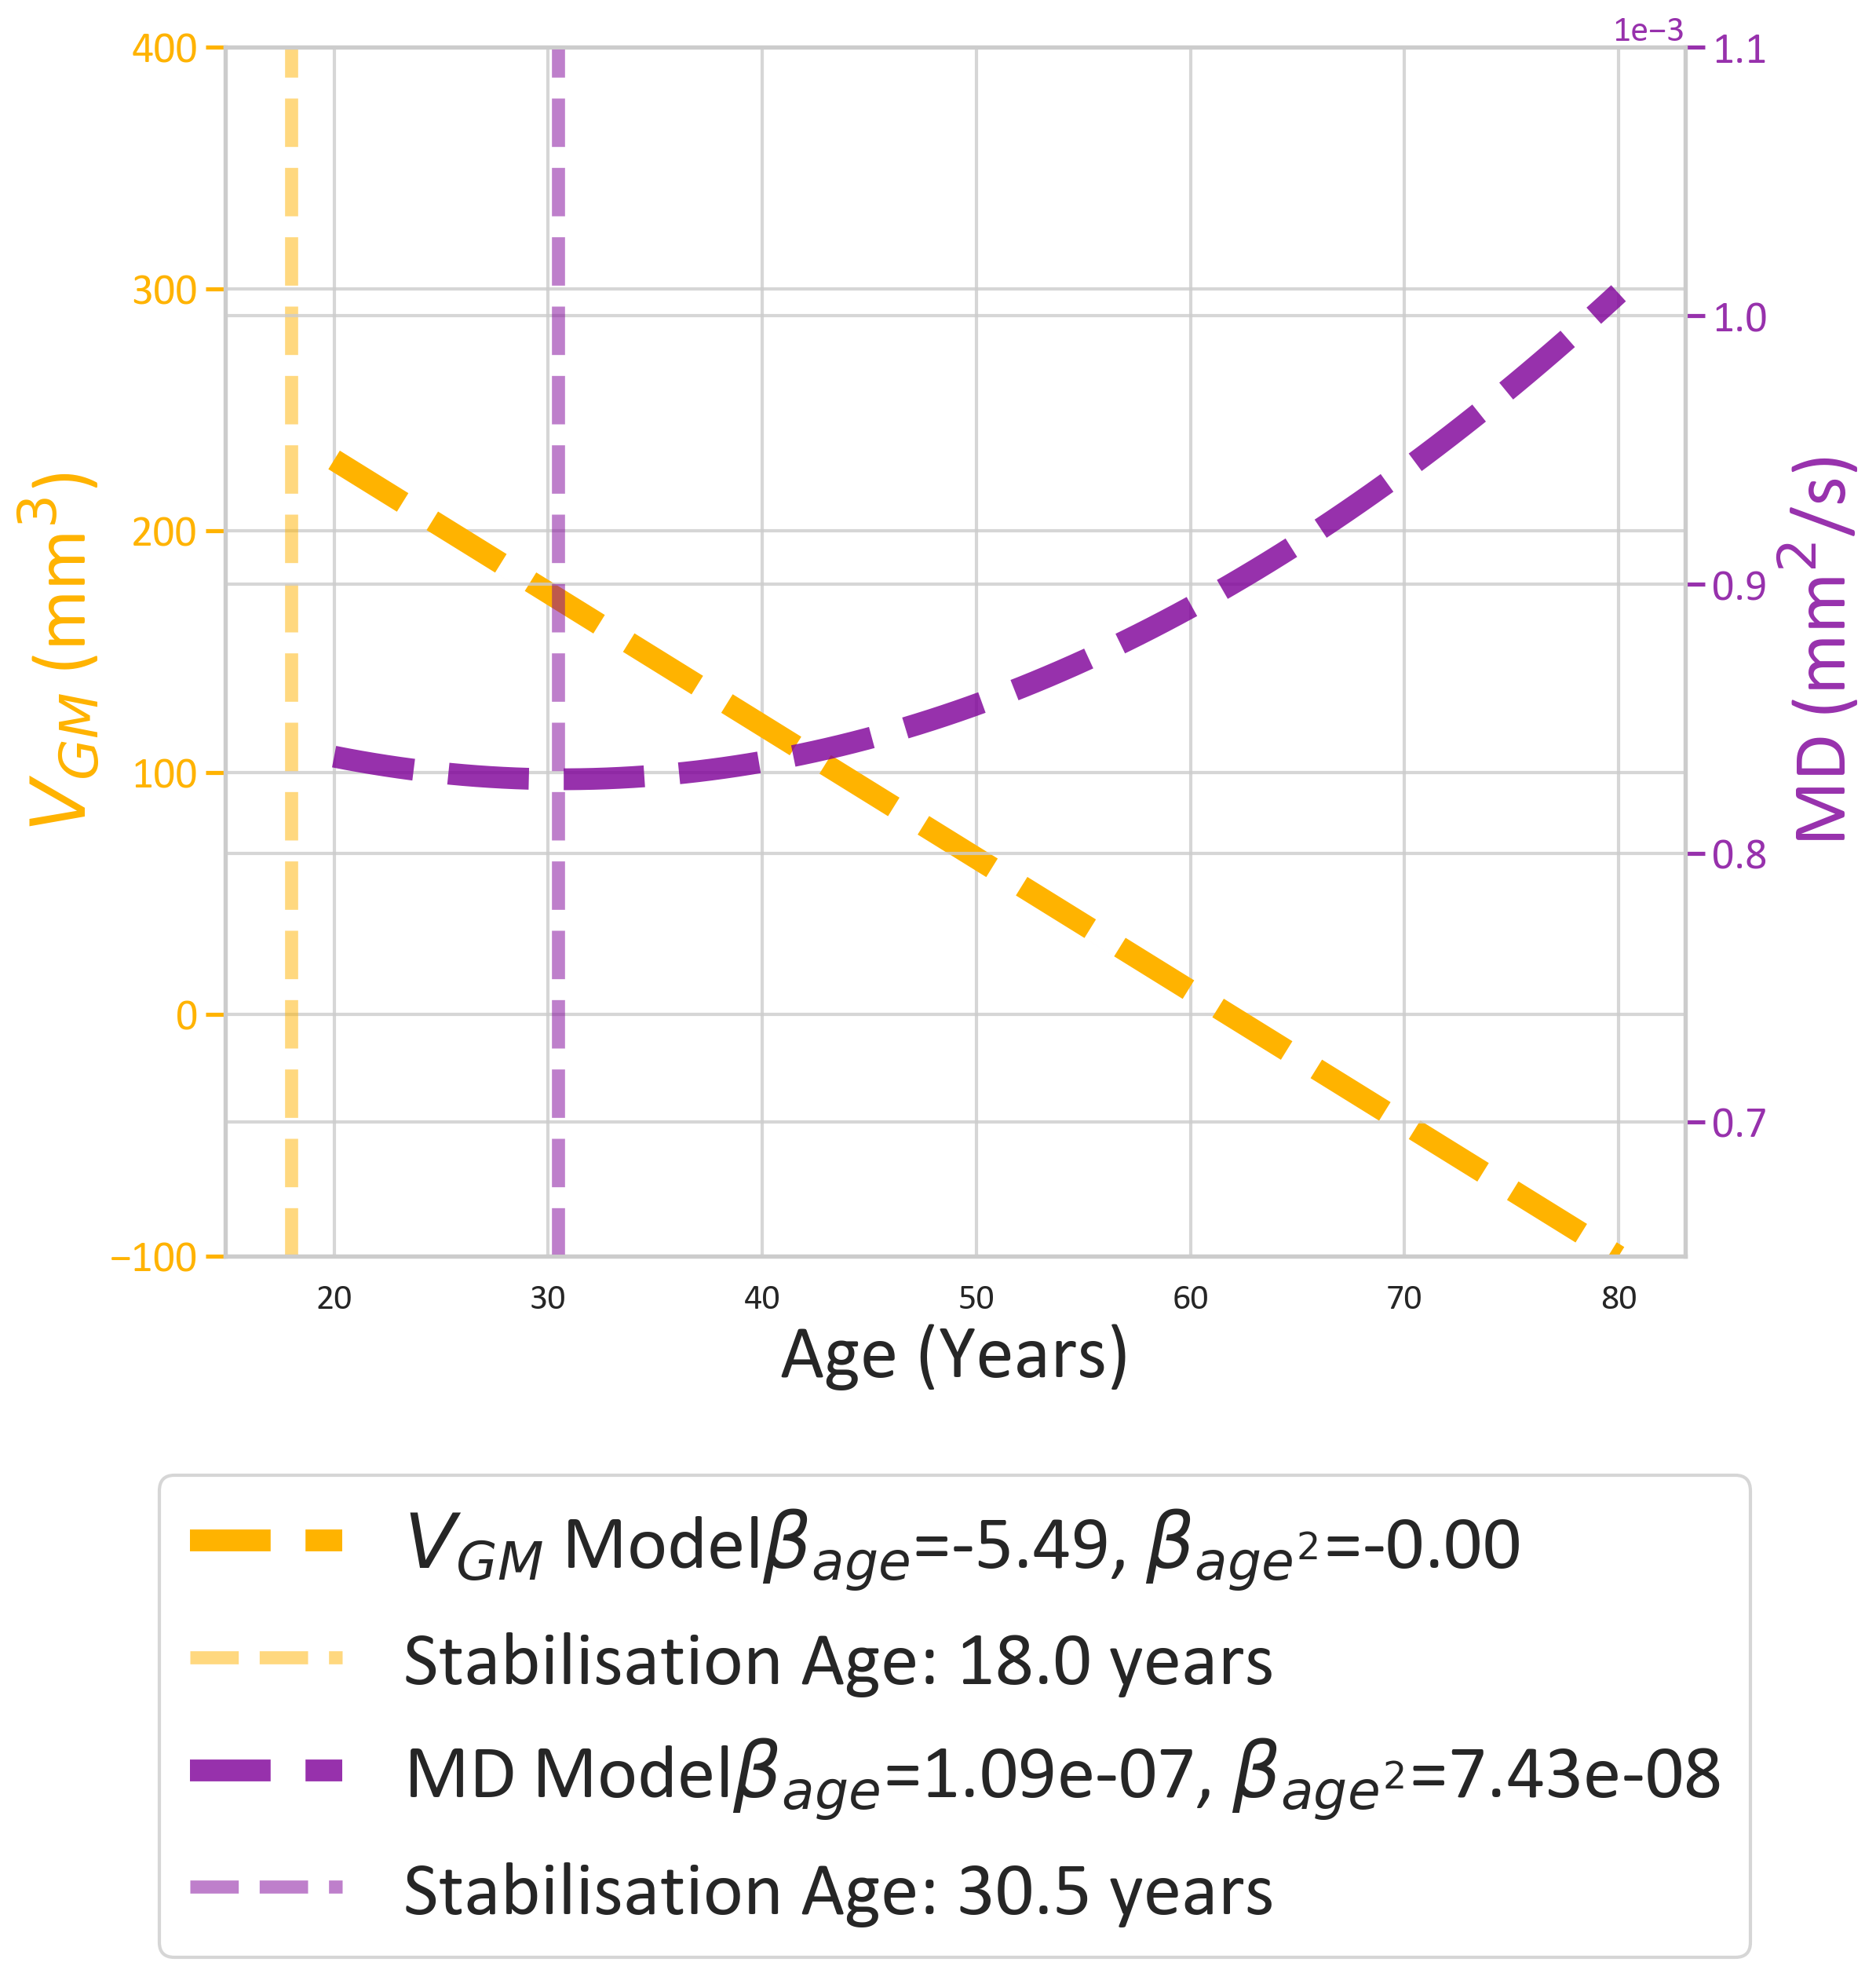

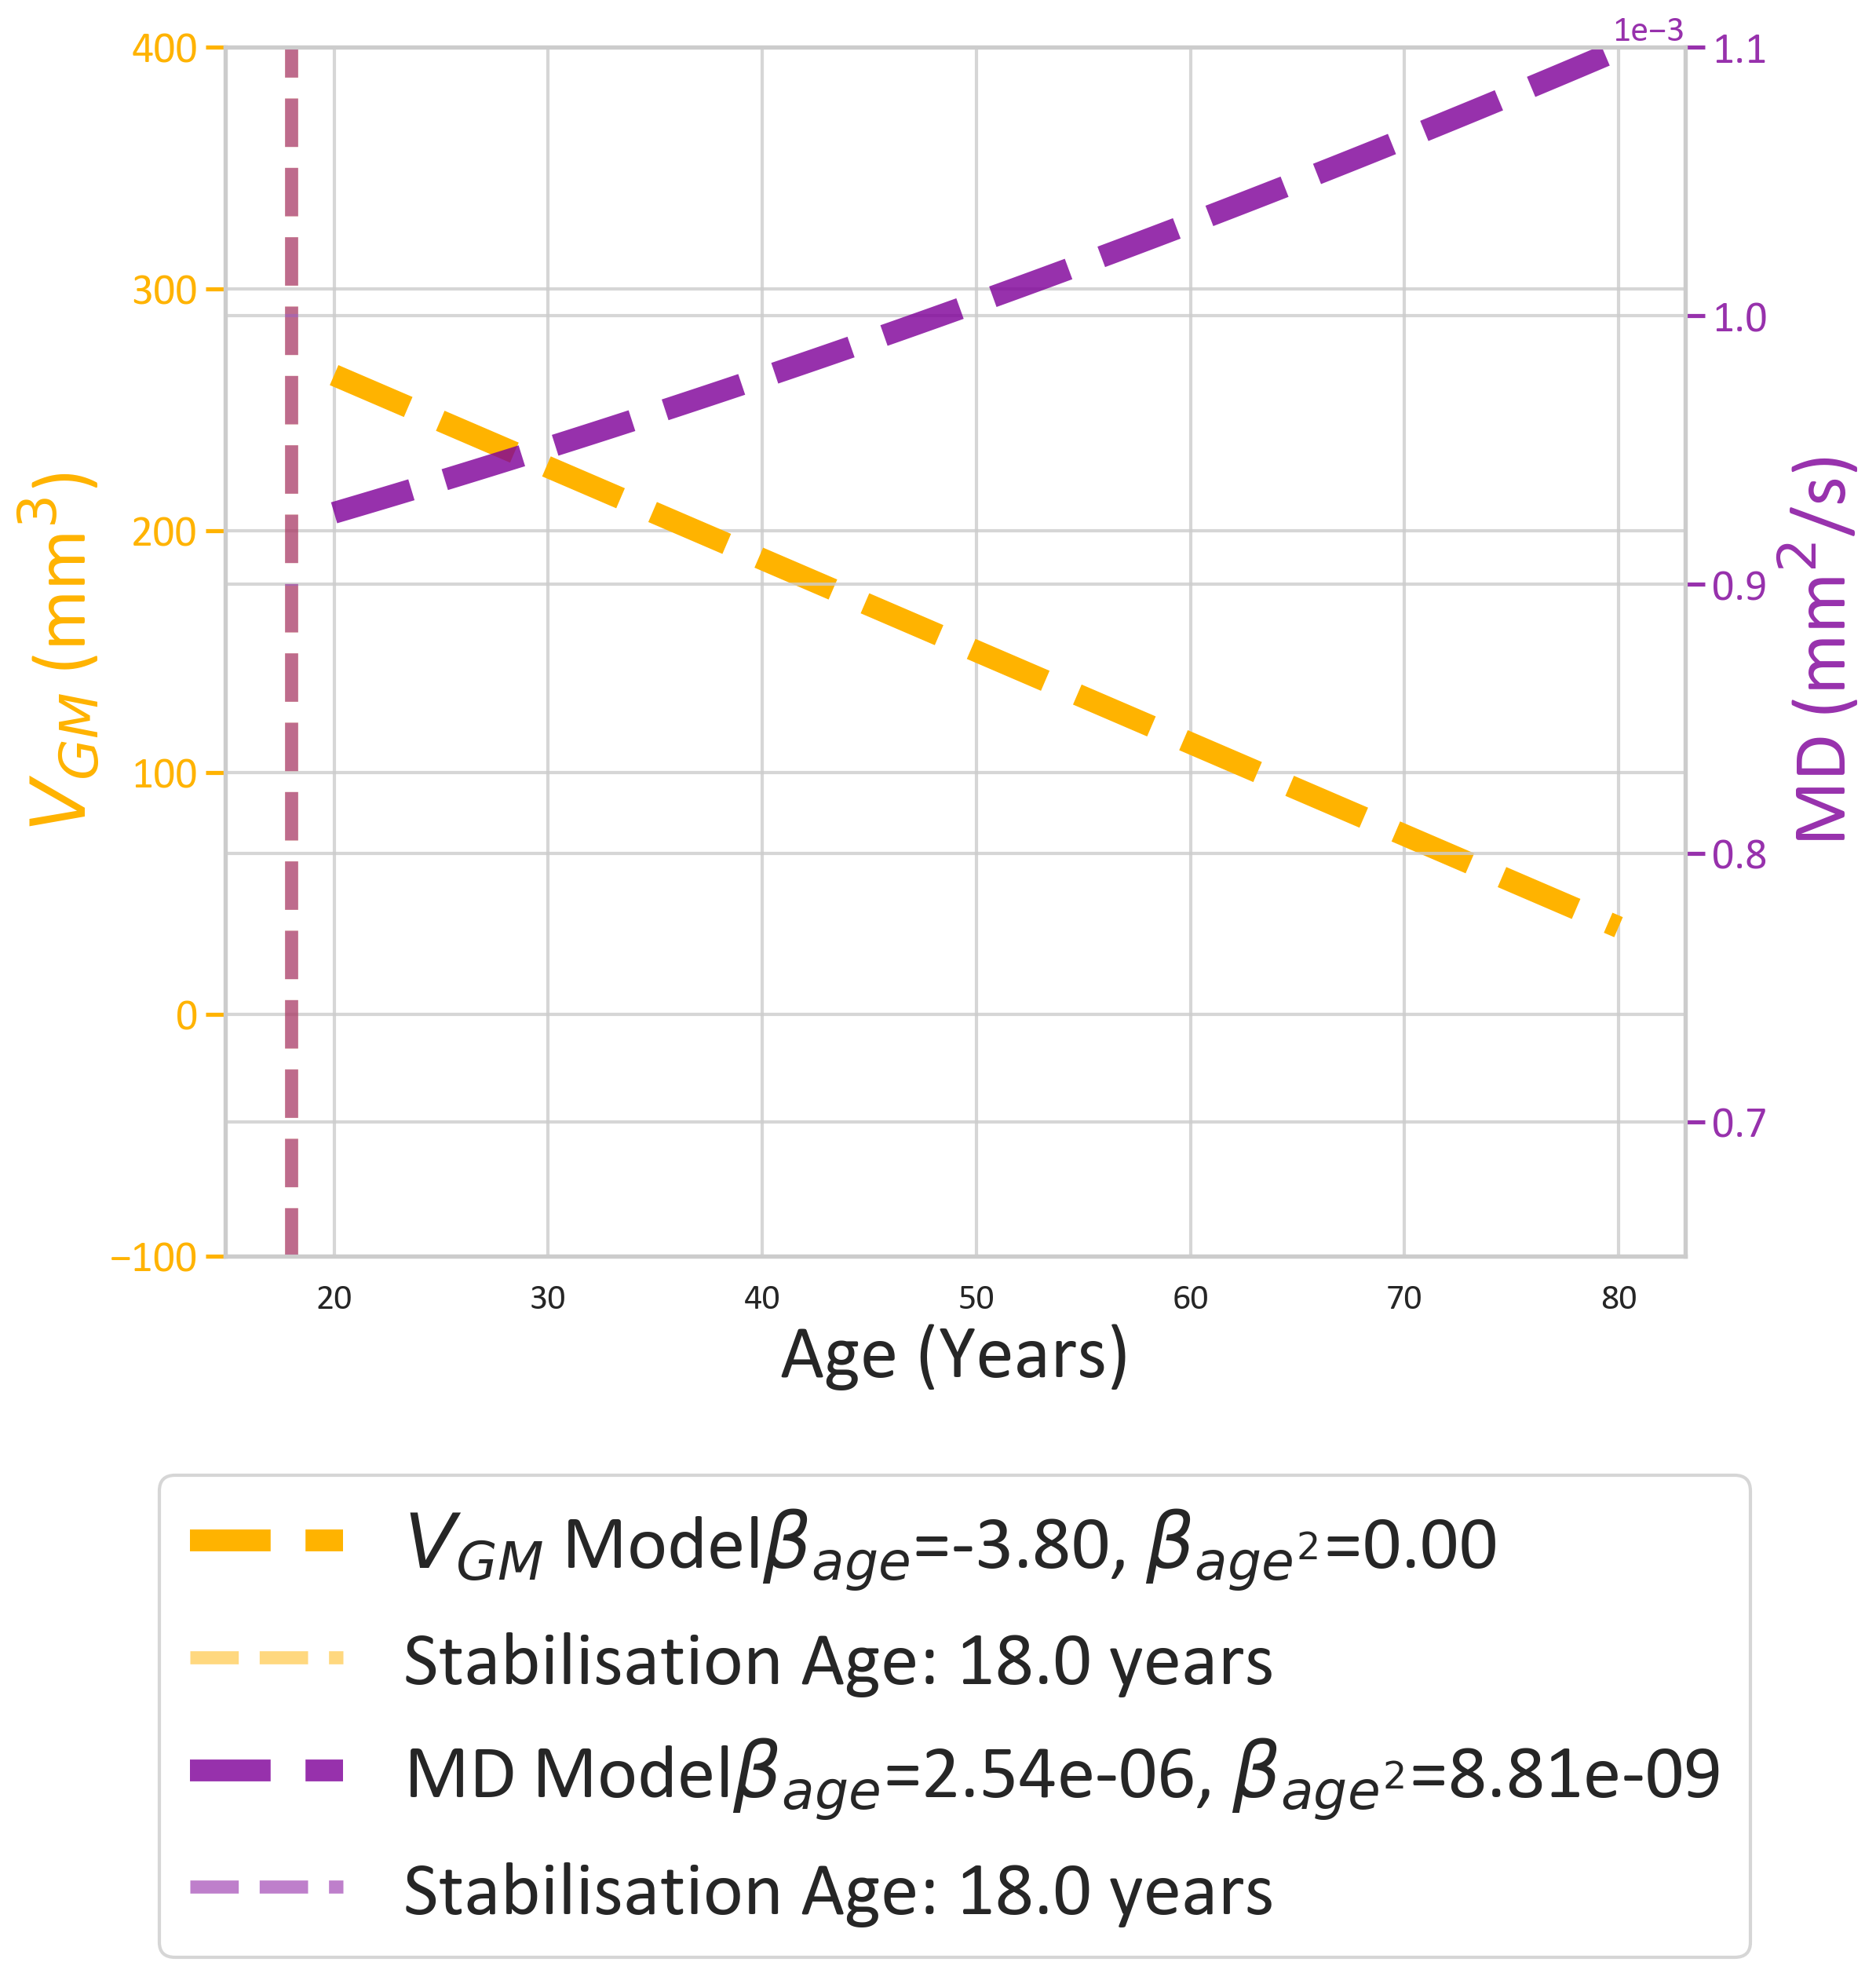

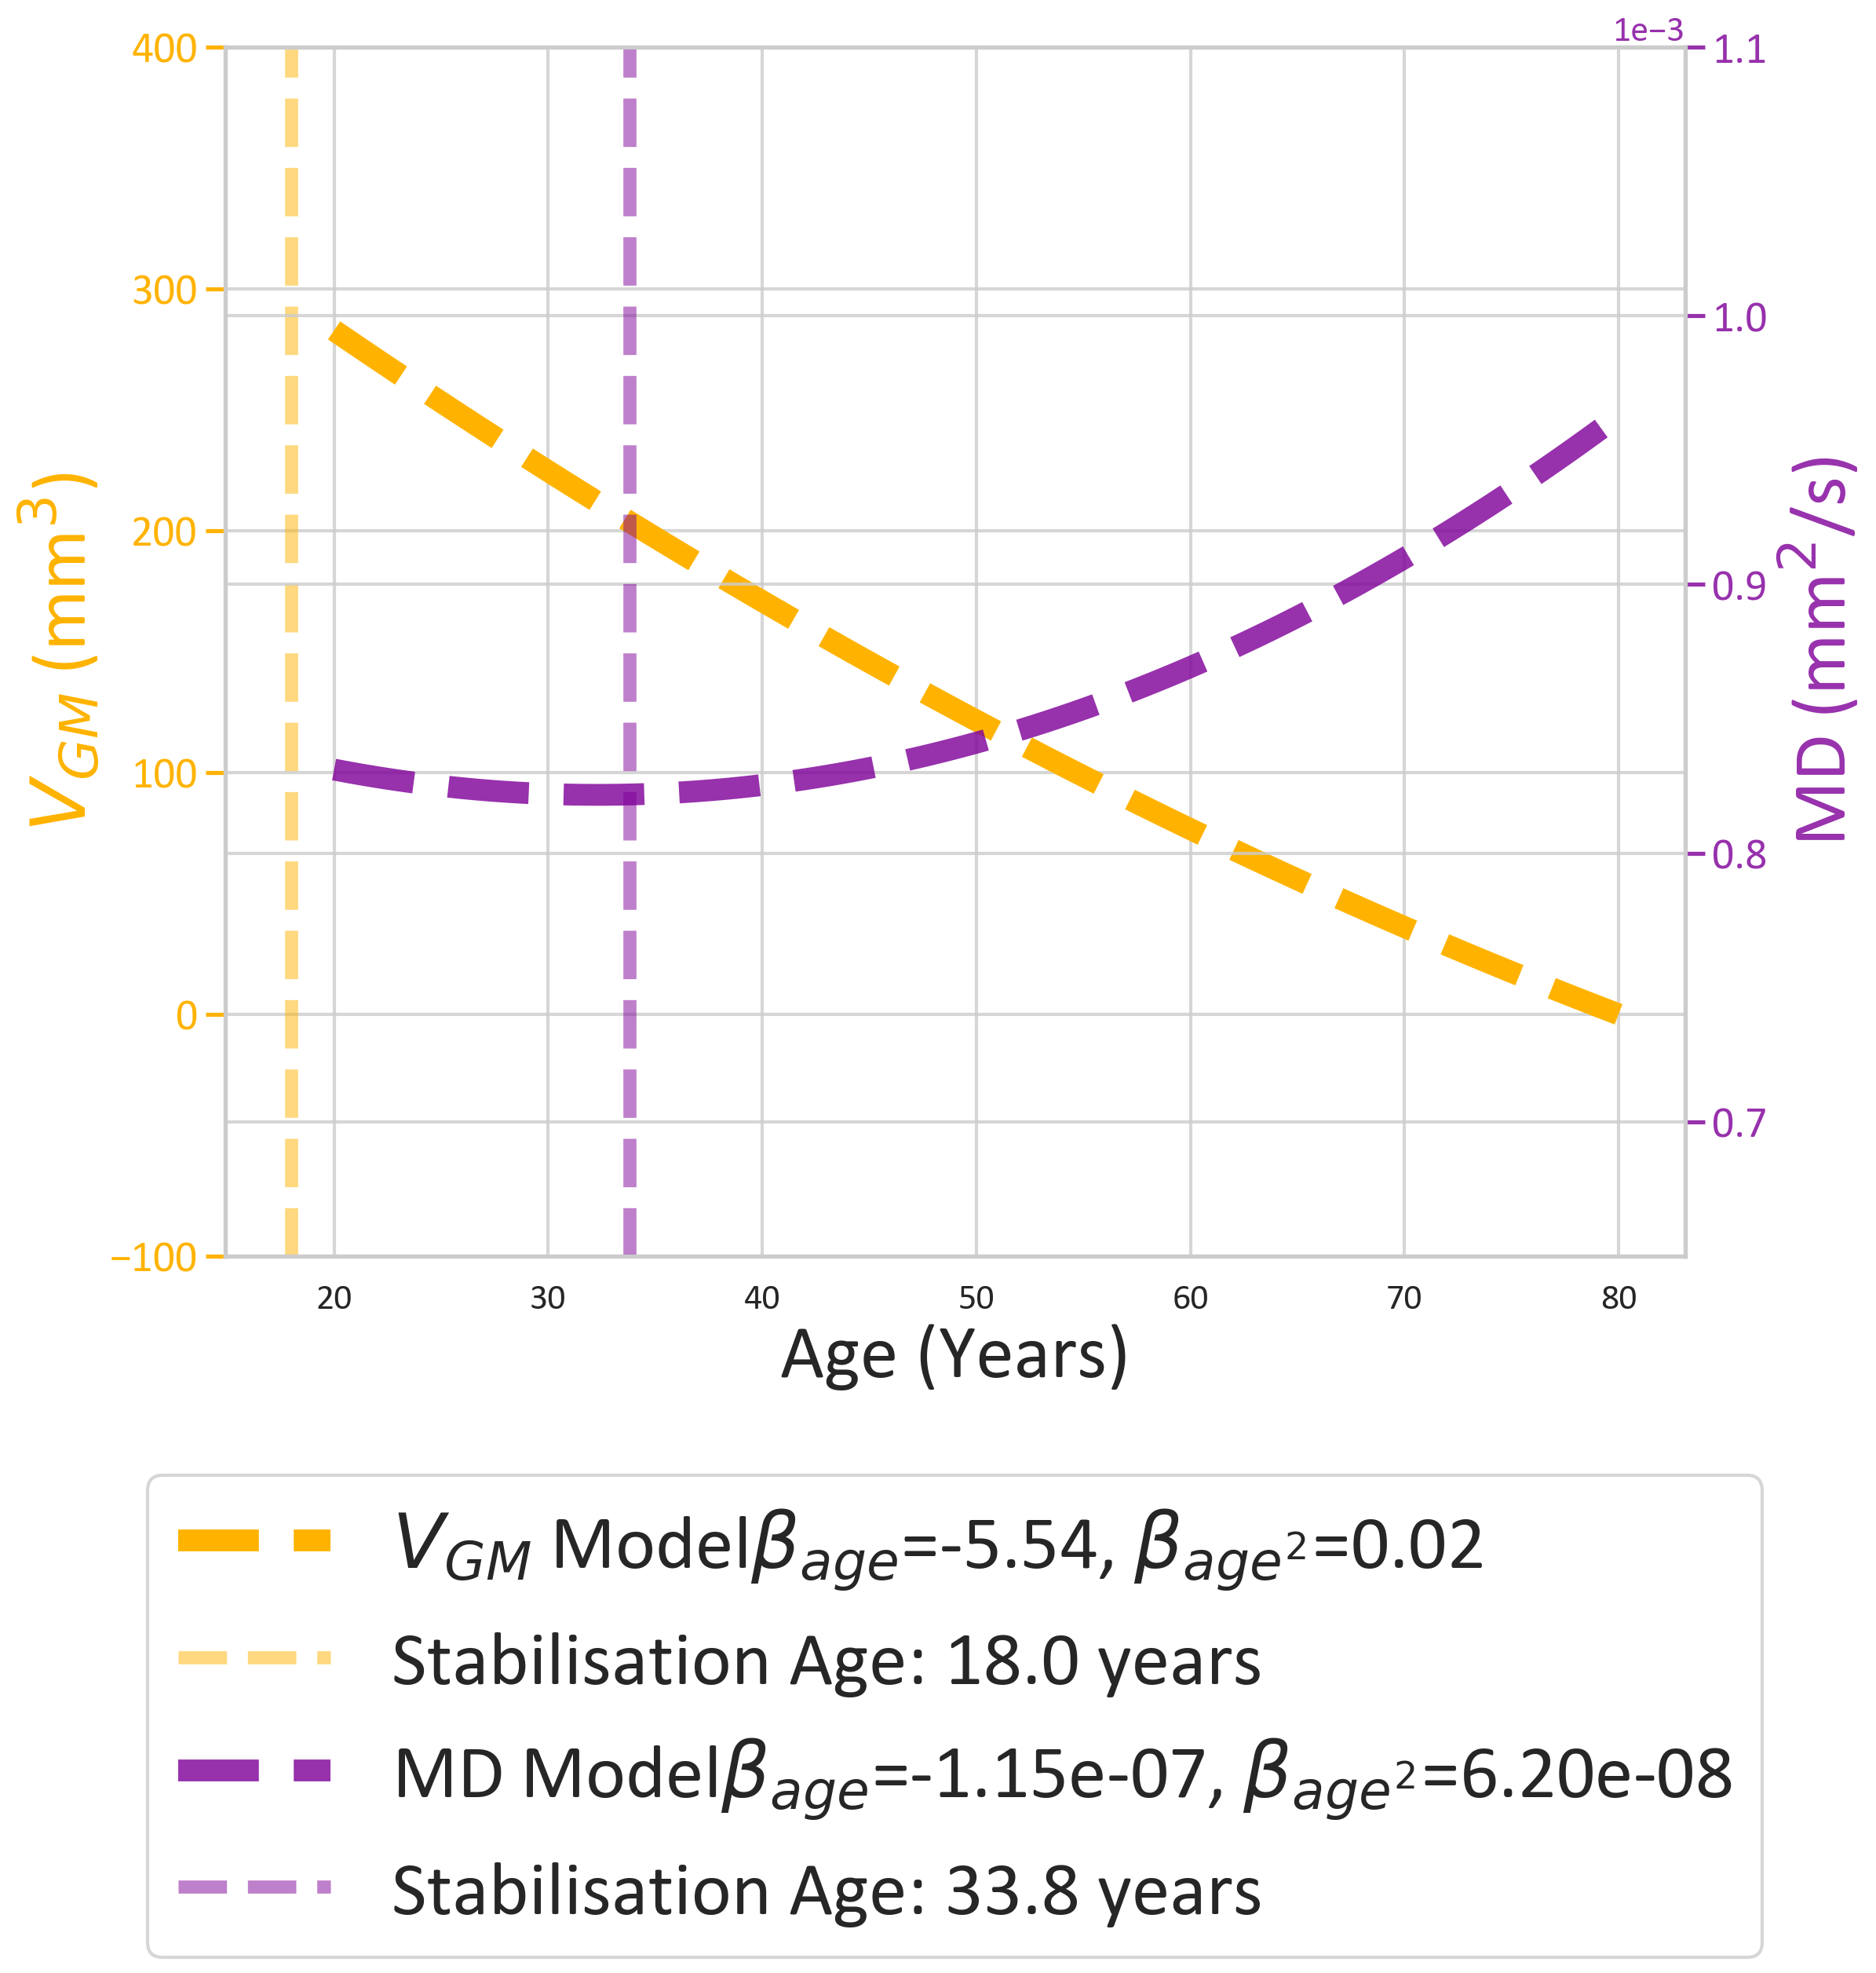

Error: Cluster ID 4 not found. Please choose a valid ID from 0 to 4.


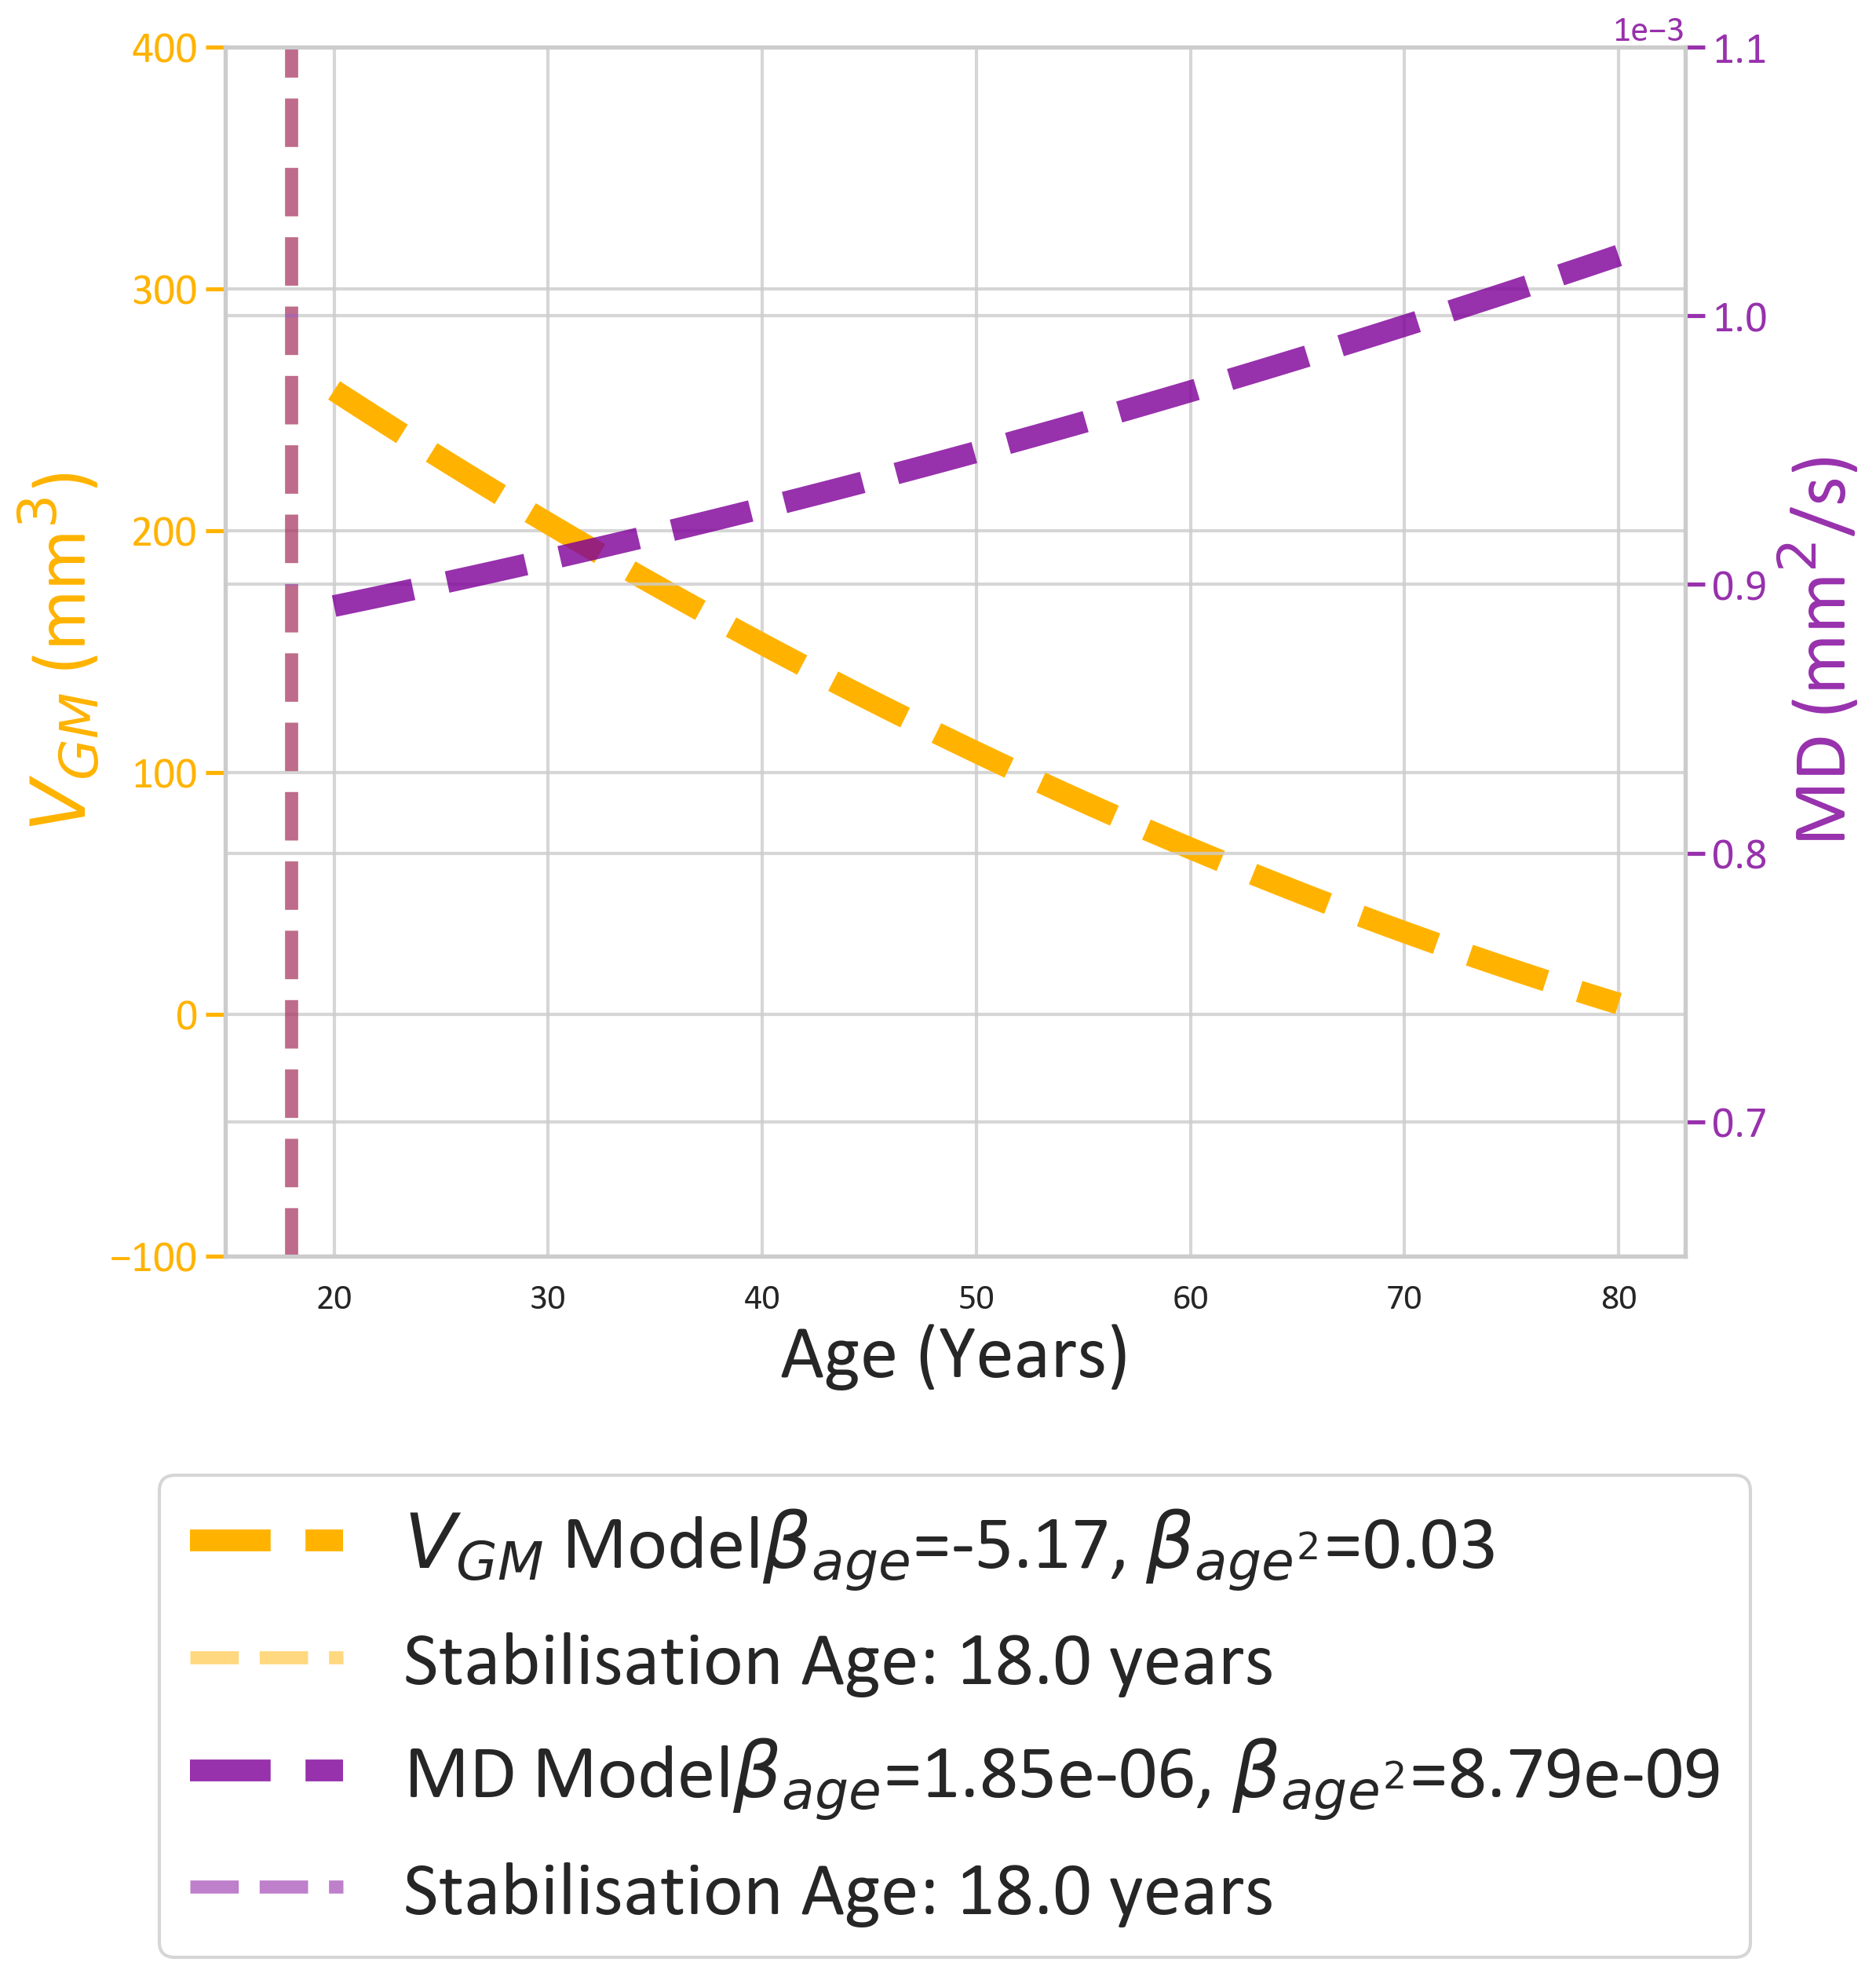

In [31]:
metrics_visualization = {
    "adc": "MD",
    "gm_vol": "$V_{GM}$",
}

ylims = {
    # "adc": (-0.0002, 0.0002),
    "adc": (0.65e-3, 1.1e-3),
    "gm_vol": (-100, 400),
}

units = {
    "adc": "mm$^2$/s",
    "gm_vol": "mm$^3$",
}

# Anchor centroid curves to an observed scale if intercepts are missing.
ref_age_by_metric = {m: all_data[m]["age_at_scan"].median() for m in metrics}
weights_series = pd.Series(weights, index=parcels.index)

baseline_by_cluster = pd.DataFrame(index=range(1, best_k + 1), columns=metrics, dtype=float)
for metric in metrics:
    ref_age = ref_age_by_metric[metric]
    mean_age = mean_age_by_metric[metric]
    for cluster_id in range(1, best_k + 1):
        region_ids = clusters.index[clusters["cluster"] == cluster_id]
        preds = []
        pred_weights = []
        for region_id in region_ids:
            quad_comp_pvalue = regional_results[metric]["w_compare"].loc[region_id, "p_corrected"]
            quad_comp_delta_aic = regional_results[metric]["w_compare"].loc[region_id, "delta_AIC"]
            if (quad_comp_delta_aic < -15) and (quad_comp_pvalue < 0.05):
                model_df = regional_results[metric]["quad_w"]
                beta2 = model_df.loc[region_id, "beta2"]
            else:
                model_df = regional_results[metric]["lin_w"]
                beta2 = 0
            intercept = model_df.loc[region_id, "intercept"]
            beta1 = model_df.loc[region_id, "beta1"]
            age_c = ref_age - mean_age
            pred = intercept + beta1 * age_c + beta2 * (age_c ** 2)
            if np.isfinite(pred):
                preds.append(pred)
                pred_weights.append(weights_series.loc[region_id])
        if preds:
            preds = np.asarray(preds)
            pred_weights = np.asarray(pred_weights)
            lo, hi = np.nanpercentile(preds, [5, 95])
            mask = (preds >= lo) & (preds <= hi)
            if mask.any():
                baseline = np.average(preds[mask], weights=pred_weights[mask])
            else:
                baseline = np.average(preds, weights=pred_weights)
            baseline_by_cluster.loc[cluster_id, metric] = baseline
        else:
            baseline_by_cluster.loc[cluster_id, metric] = np.nan

# Choose the cluster ID to visualize (e.g., 0, 1, 2 based on your chosen_k)
# You can change this value to visualize different clusters
for cluster_id_to_visualize in range(1, best_k + 1):
    if cluster_id_to_visualize not in centroids.index:
        print(
            f"Error: Cluster ID {cluster_id_to_visualize} not found. Please choose a valid ID from 0 to {best_k-1}."
        )
    else:
        # Get the representative coefficients for the selected cluster
        cluster_coeffs = centroids.loc[cluster_id_to_visualize]
        ages = np.linspace(20, 80, 100)  # From 20 to 80 years, 100 points
        fig, ax1 = plt.subplots(figsize=(12, 10))
        ax2 = ax1.twinx()

        lines = []
        labels = []

        for metric, c, ax in zip(["gm_vol", "adc"], [COL_RAW, COL_WEIGHTED], [ax1, ax2]):
            mean_age = mean_age_by_metric[metric]
            # Extract coefficients for the linear and quadratic models
            intercept = cluster_coeffs.get(f"{metric}_intercept", np.nan)
            beta1 = cluster_coeffs.get(f"{metric}_beta1", 0)  # Default to 0 if not present
            beta2 = cluster_coeffs.get(f"{metric}_beta2", 0)  # Default to 0 if not present

            if not np.isfinite(intercept):
                ref_age = ref_age_by_metric[metric]
                baseline = baseline_by_cluster.loc[cluster_id_to_visualize, metric]
                if not np.isfinite(baseline):
                    baseline = 0.0
                age_c = ref_age - mean_age
                intercept = baseline - beta1 * age_c - beta2 * (age_c ** 2)

            age_c = ages - mean_age
            predicted_volume_quadratic = intercept + beta1 * age_c + beta2 * (age_c ** 2)

            label = f"{metrics_visualization[metric]} Model"
            if metric == "adc":
                label += "$\\beta_{{age}}$={:.2e}, $\\beta_{{age^2}}$={:.2e}".format(beta1, beta2)
            else:
                label += "$\\beta_{{age}}$={:.2f}, $\\beta_{{age^2}}$={:.2f}".format(beta1, beta2)

            lines += ax.plot(
                ages,
                predicted_volume_quadratic,
                label=label,
                color=c,
                linestyle="--",
                linewidth=10,
            )

            y_min = np.nanmin(predicted_volume_quadratic)
            y_max = np.nanmax(predicted_volume_quadratic)
            pad = max((y_max - y_min) * 0.1, abs(y_max) * 0.05, 1e-6)
            auto_ylim = (y_min - pad, y_max + pad)
            manual_ylim = ylims[metric]
            if manual_ylim[0] <= y_max and manual_ylim[1] >= y_min:
                ax.set_ylim(manual_ylim)
            else:
                ax.set_ylim(auto_ylim)

            labels.append(label)
            ax.set_xlabel("Age (Years)", fontsize=35)
            ax.set_ylabel(
                f"{metrics_visualization[metric]} ({units[metric]})", fontsize=35, color=c
            )
            ax.tick_params(axis="y", which="major", labelsize=20, color=c, labelcolor=c)
            if metric == "adc":
                # set ticks to scientific notation
                ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
            if "gm_vol_age_star" in features:
                # Add a vertical line for the age_star
                age_star = cluster_coeffs.get(f"{metric}_age_star")
                age_star = age_star if age_star != 0 else mean_age_by_metric[metric]
                lines += [
                    ax.axvline(
                        x=age_star,
                        color=c,
                        linestyle="dashed",
                        linewidth=6,
                        label=f"Stabilisation Age: {age_star:.1f} years",
                        alpha=0.5,
                    )
                ]
                labels.append(f"Stabilisation Age: {age_star:.1f} years")

        ax.tick_params(axis="x", which="major", labelsize=20)

        plt.grid(True)
        # set legend below the plot
        plt.legend(lines, labels, fontsize=35, loc="upper center", bbox_to_anchor=(0.5, -0.15))
        plt.show()
        savefig_nice(fig, out_dir / f"cluster_{cluster_id_to_visualize}_trend.png")


/tmp/ipykernel_3009598/1459870668.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


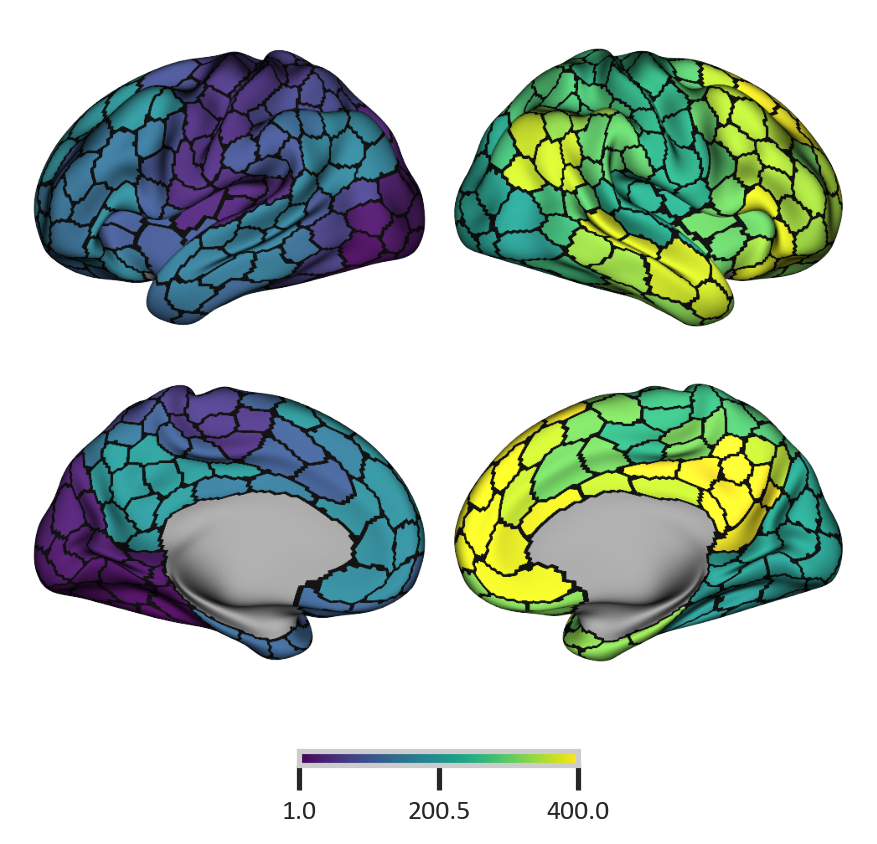

In [32]:
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from brainspace.datasets import load_parcellation

surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]
p = Plot(lh, rh)

# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")
p.add_layer({"left": lh_parc, "right": rh_parc}, cbar=True)

p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)
fig = p.build()
fig.show()

In [33]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

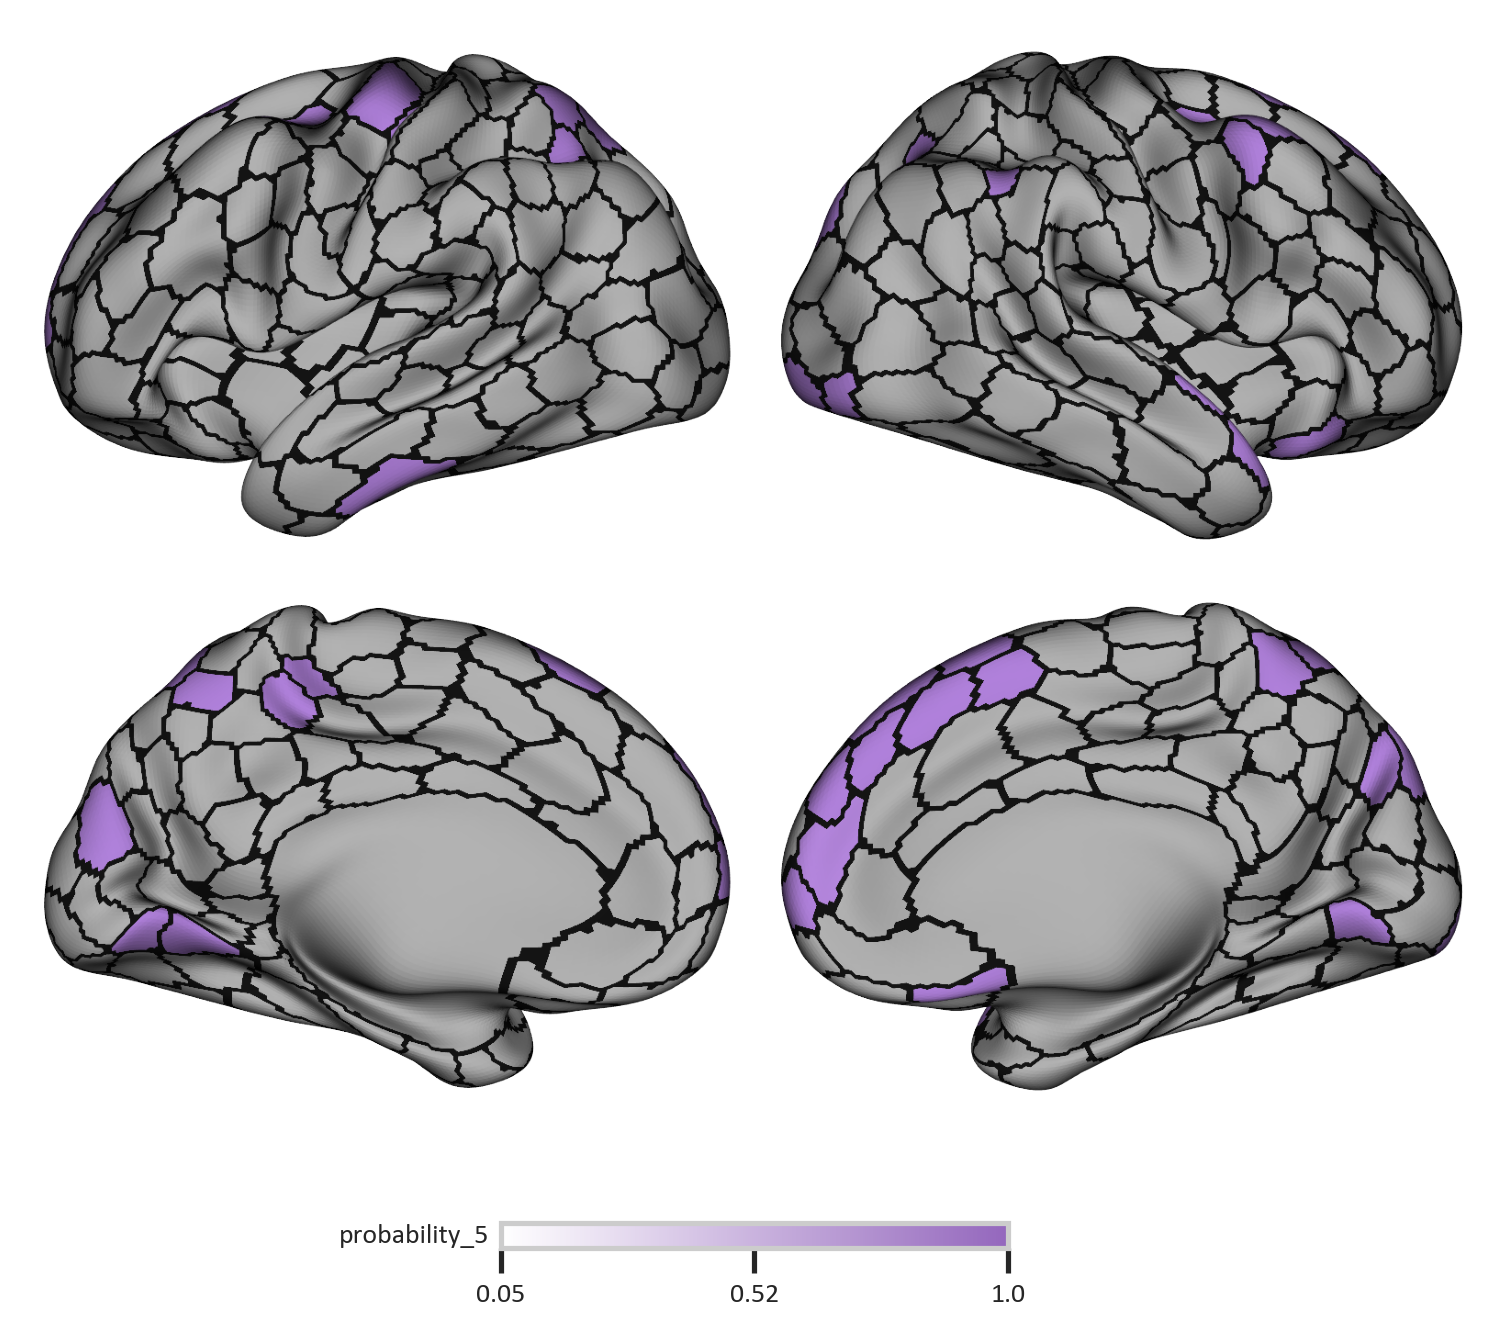

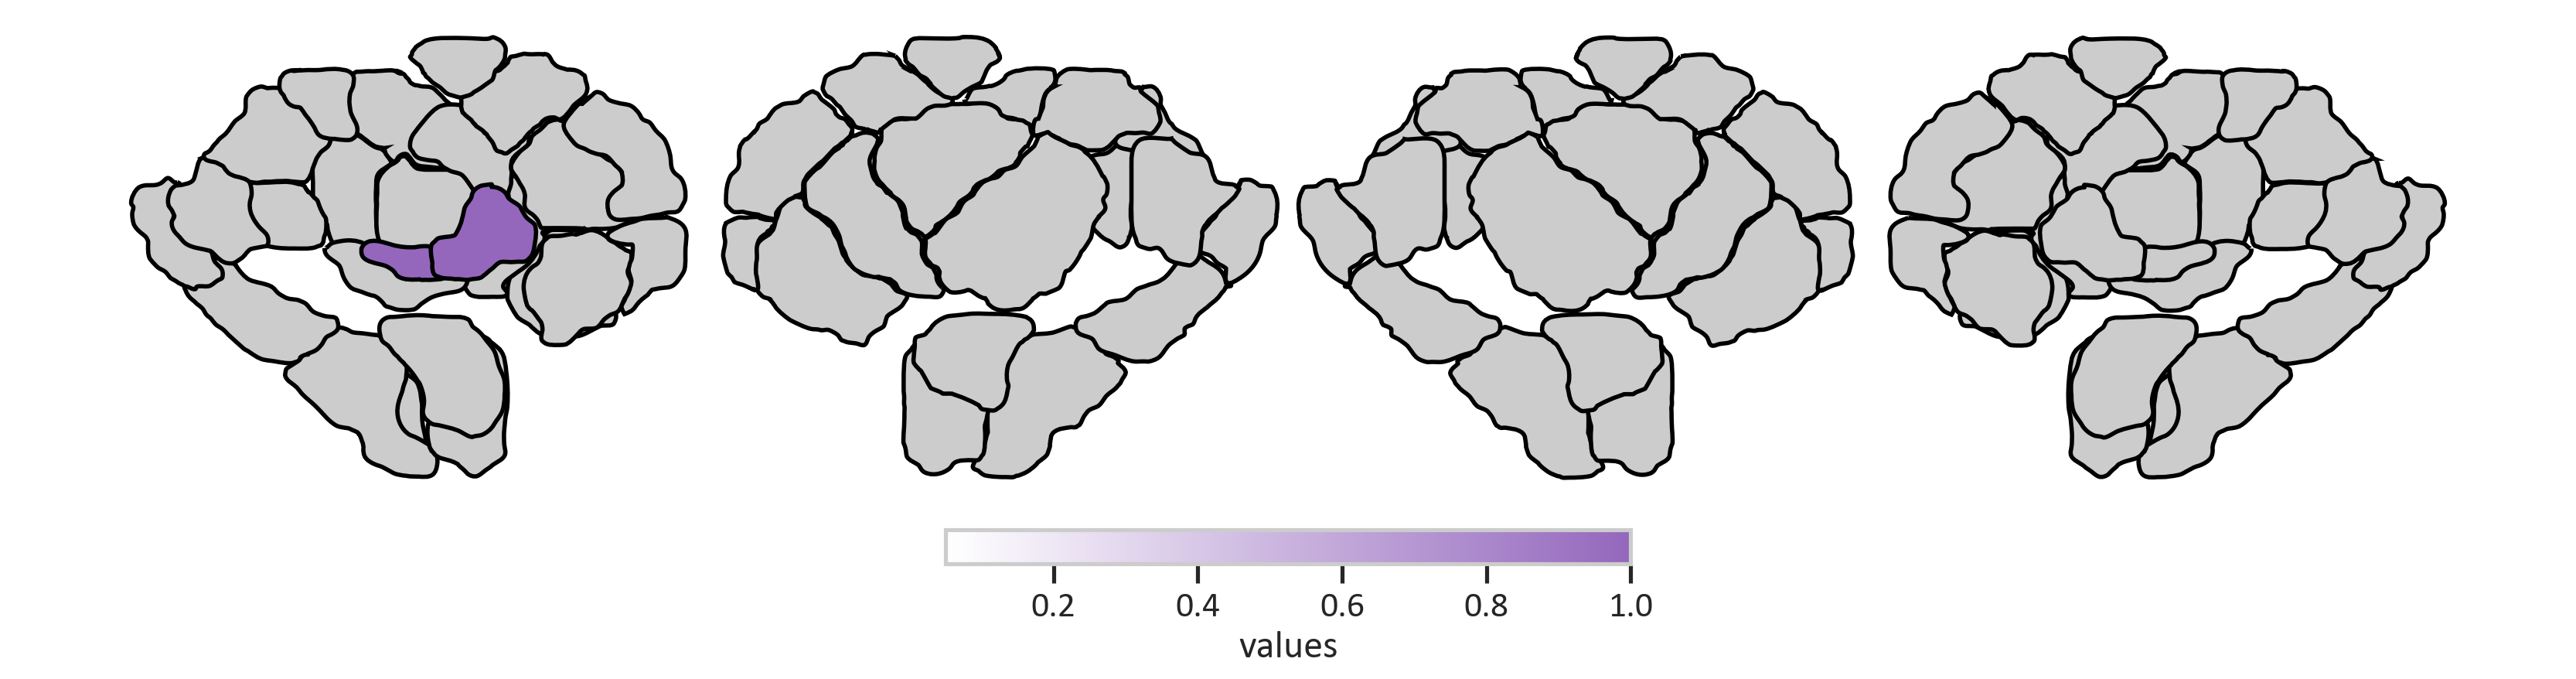

In [40]:
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

# vis_df = w_compare
# value_column = "log(f)"
vis_df = clusters.copy()
# value_column = "r2_adj"
value_column = "probability_5"
p_column = "p_corrected_beta2"

prob_threshold = 0.05

# create a colormap with categorical colors (the same number of colors as clusters)
clusters_cmap = mpl.colors.ListedColormap(sns.color_palette("tab10", best_k))
if "prob" not in value_column:
    cmap = clusters_cmap
else:
    # get cluster colors from clusters_cmap
    vis_cluster = int(value_column.split("_")[-1])  # e.g., "probability_1" → "1"
    # end color is the color of the cluster
    end_color = clusters_cmap.colors[vis_cluster - 1]  # -1 for zero-indexing
    # create a gradient from white to the cluster color
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "cluster_gradient",
        [COL_WHITE, end_color],
        N=256,  # Number of colors in the gradient
    )
# if use_weights:
# else:
#     cmap = clusters_cmap
value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    # if (row[p_column] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
    value = float(row[value_column])
    if "prob" in value_column and value < prob_threshold:
        value = np.nan
    # else:
    #     value = np.nan  # Set to NaN if not significant or below value_threshold
    if value_column == "log(f)":
        if vis_df.loc[i, "delta_AIC"] > -15:
            value = np.nan

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation


vmin = (
    1 if "prob" not in value_column else prob_threshold
)  # Set vmin to 1 for log(f) or 0 for probabilities
vmax = (
    best_k if "prob" not in value_column else 1
)  # Set vmax to best_k for log(f) or 1 for probabilities


# vmin = 0
# vmax = 1  # Assuming clusters are labeled from 0 to best_k-1
# cmap = "Purples"

# Corrected loop for plotting each hemisphere independently
# for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
#     ["left", "right"],  # The key for surfplot's dictionary
#     [lh, rh],  # The surface object for the current hemisphere
#     [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
#     [lh_parc, rh_parc],  # The parcellation for the current hemisphere
# ):
# ---------------------------------------------------------------------
# 5.  BUILD THE PLOT
# ---------------------------------------------------------------------
# pref_surf = {
#     "surf_lh": hemi_surf_data if hemi_key == "left" else None,
#     "surf_rh": hemi_surf_data if hemi_key == "right" else None,
# }

# views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]
p = Plot(
    lh,
    rh,
    # Unpack the surface dictionary
    # views=["medial", "lateral"],  # Show both medial and lateral for this hemi
    size=(800, 600),  # px; change as needed
    zoom=1.6,
    layout="grid",  # Horizontal layout for side-by-side views
    mirror_views=True,  # Set to False, as we are plotting one hemi at a time
)

# ---- main data layer -------------------------------------------------
# Pass only the data for the current hemisphere
# The dictionary now contains only one key-value pair for the current hemisphere
p.add_layer(
    {"left": data_lh_mapped, "right": data_rh_mapped},
    #     # cmap="Purples",
    cmap=cmap,
    #     # cmap="coolwarm",
    color_range=(vmin, vmax),  # Use symmetric range
    #     # norm=norm,  # Apply the symmetric normalization
    cbar_label=value_column,
    cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
)
# # ---- outline layer ---------------------------------------------------
p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)

fig = p.build(
    # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
)  # Added cbar_kws for better cbar display
# # save figure
savefig_nice(fig, out_dir.resolve() / f"{value_column}.png", dpi=400)


from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


# for hemi in ["L", "R"]:

fig = plot_subcortical_data(
    subcort_df,
    atlas="Melbourne_S3",
    show_legend=True,
    hemisphere="both",
    cmap=cmap,
    # cmap=cmap,
    line_color="black",
    line_thickness=2,
    vmin=vmin,
    vmax=vmax,
    show_figure=False,
)

# save figure
savefig_nice(fig, out_dir / f"subcort_{value_column}.png", dpi=400)

In [41]:
import pandas as pd
import numpy as np

# 1. Prepare your data
labels_unweighted = pd.read_csv(OUTPUT_DIR / "unweighted" / "region_clusters.csv")
labels_weighted = pd.read_csv(OUTPUT_DIR / "weighted" / "region_clusters.csv")
# You need a dataframe where each row is a brain region
# 'cluster_unweighted' (K=7) and 'cluster_weighted' (K=5)
# data = {
#     'unweighted': labels_unweighted, # your K=7 labels
#     'weighted': labels_weighted     # your K=5 labels
# }
# df = pd.DataFrame(data)
df = parcels.copy()
df["unweighted"] = labels_unweighted["cluster"]  # zero-indexed
df["weighted"] = labels_weighted["cluster"]      # zero-indexed


# calulcate dice scores for the two labelings
def dice_score(set_a, set_b):
    intersection = len(set_a.intersection(set_b))
    if len(set_a) + len(set_b) == 0:
        return 1.0  # Both sets are empty
    return (2 * intersection) / (len(set_a) + len(set_b))
dice_matrix = pd.DataFrame(index=sorted(df['unweighted'].unique()), columns=sorted(df['weighted'].unique()))
for u in dice_matrix.index:
    for w in dice_matrix.columns:
        set_u = set(df.index[df['unweighted'] == u])
        set_w = set(df.index[df['weighted'] == w])
        dice_matrix.loc[u, w] = dice_score(set_u, set_w)
    
dice_df = pd.DataFrame(columns=["cluster","dice_score"])
for i, cluster in enumerate(sorted(dice_matrix.columns)):
    if cluster in dice_matrix.index:
        d_score = dice_matrix.loc[cluster, cluster]
        dice_df.loc[i] = [cluster, d_score]

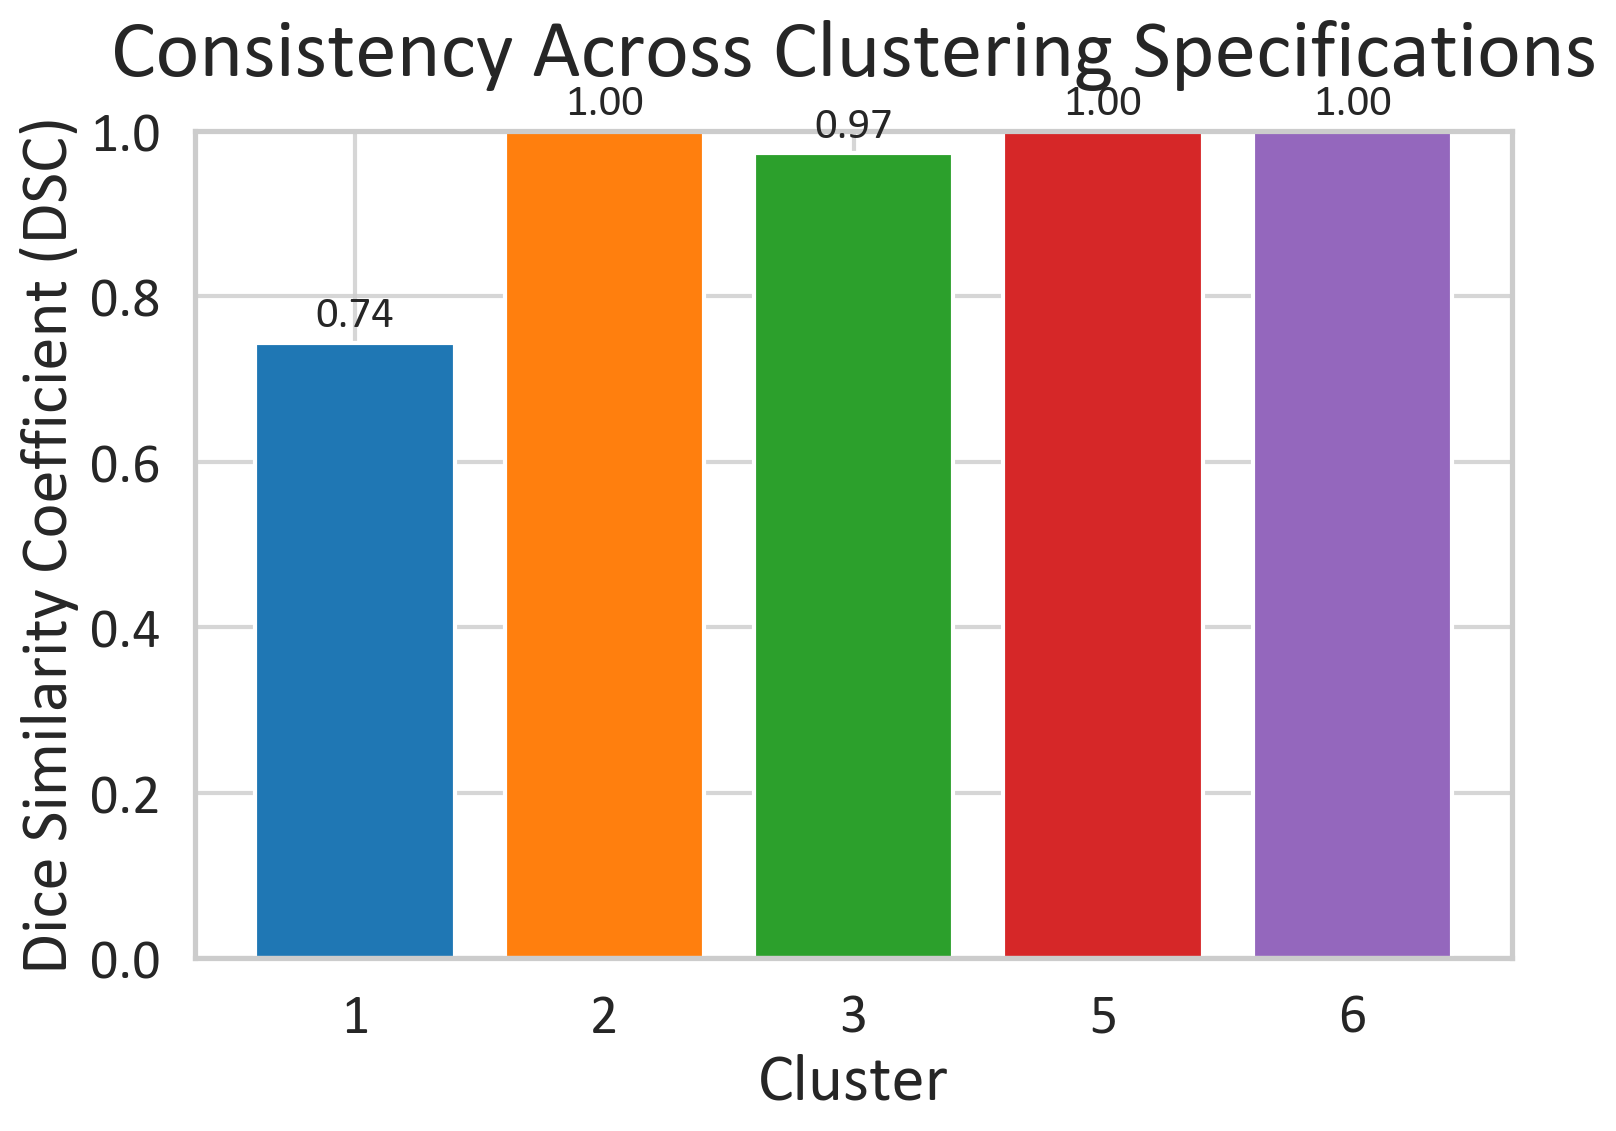

In [42]:
clusters_cmap = mpl.colors.ListedColormap(sns.color_palette("tab10", dice_df.shape[0]))
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    dice_df["cluster"].astype(int).astype(str),
    dice_df["dice_score"].astype(float),
    color=clusters_cmap.colors,
)
ax.set_xlabel("Cluster", fontsize=24)
ax.set_ylabel("Dice Similarity Coefficient (DSC)", fontsize=24)
ax.set_title("Consistency Across Clustering Specifications", fontsize=30, pad=20)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", which="major", labelsize=20)
ax.tick_params(axis="y", which="major", labelsize=20)
# add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=16,
    )
savefig_nice(fig, OUTPUT_DIR / "unweighted" / "dice_consistency.png", dpi=300)


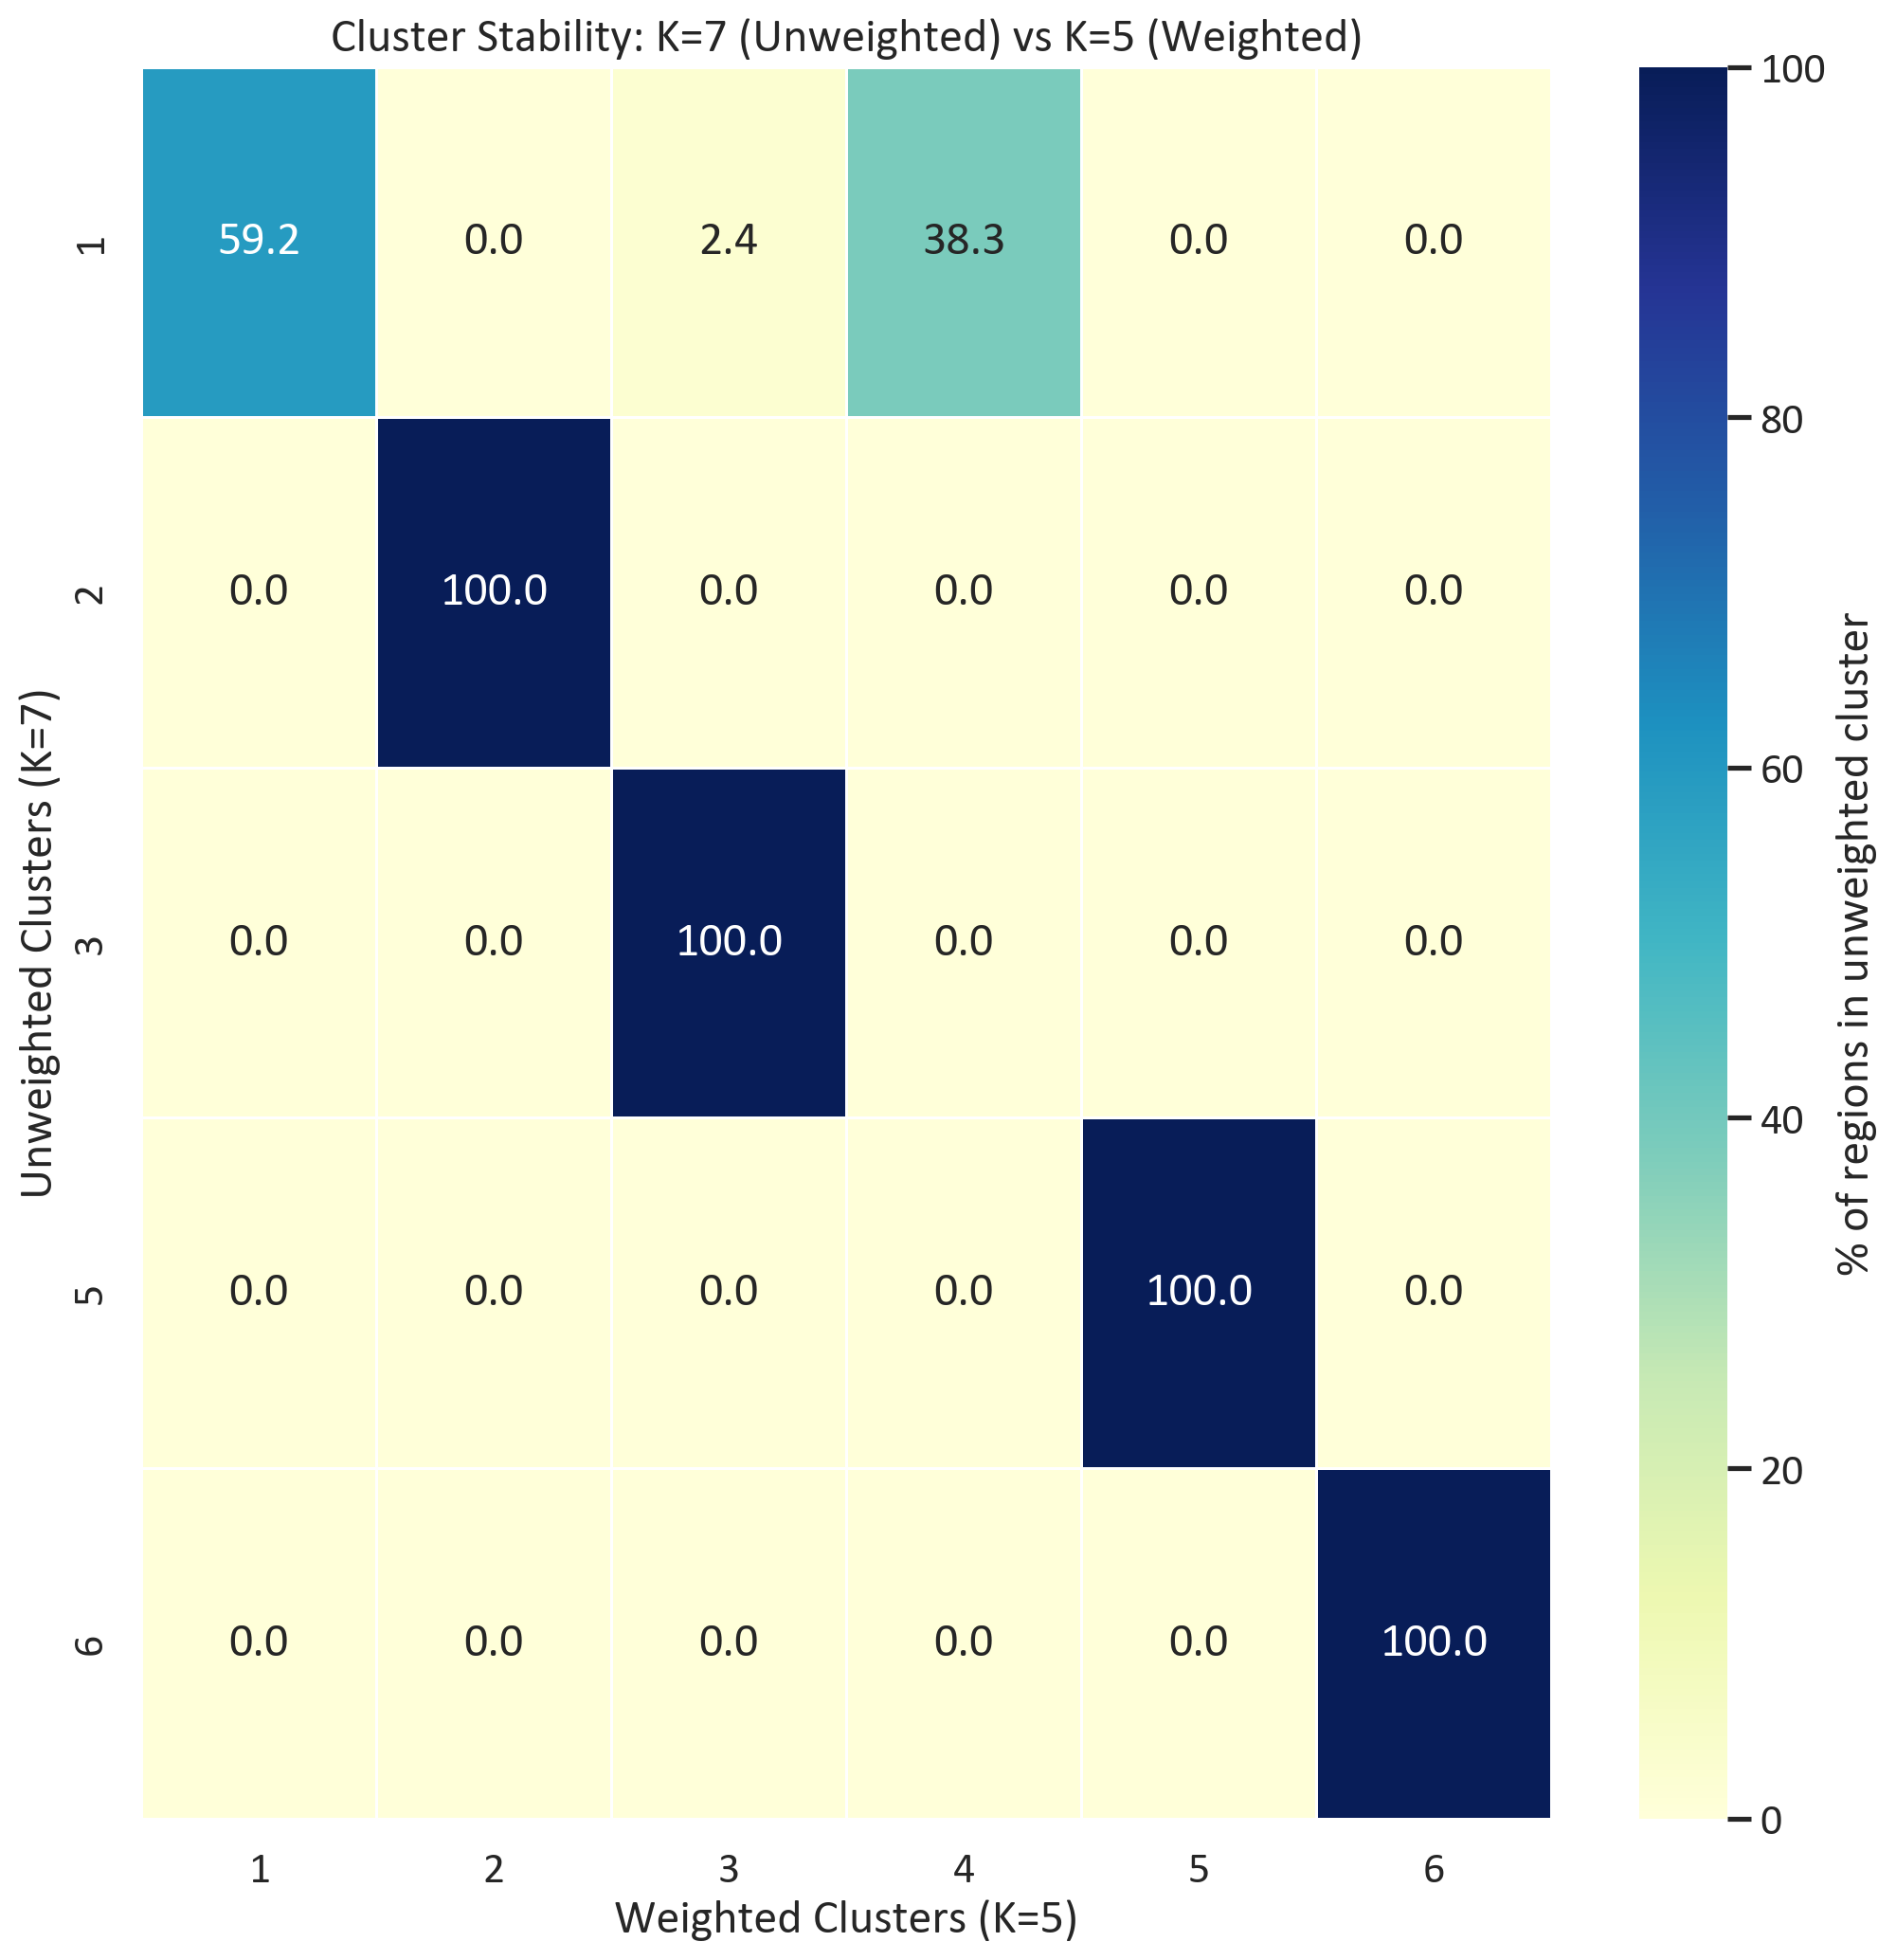

In [43]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create a cross-tabulation table
# labels_unweighted (0-6), labels_weighted (0-4)
ctab = pd.crosstab(labels_unweighted["cluster"], labels_weighted["cluster"], normalize='index') * 100

# 2. Plotting
plt.figure(figsize=(12, 12))
# sns.set_context("paper", font_size=12)

sns.heatmap(ctab, 
            annot=True, 
            fmt=".1f", 
            cmap="YlGnBu", 
            cbar_kws={'label': '% of regions in unweighted cluster'},
            linewidths=.5)

plt.title("Cluster Stability: K=7 (Unweighted) vs K=5 (Weighted)")
plt.xlabel("Weighted Clusters (K=5)")
plt.ylabel("Unweighted Clusters (K=7)")
plt.show()

In [ ]:
mapping

{np.int64(7): np.int64(5),
 np.int64(1): np.int64(1),
 np.int64(3): np.int64(3),
 np.int64(2): np.int64(2),
 np.int64(6): np.int64(4),
 np.int64(4): 6,
 np.int64(5): 7}

In [ ]:
example_rois = {
    413: {"name": "R. Putamen", "component": "Basal Ganglia"},
    447: {"name": "L. Amygdala", "component": "Limbic System"},
    168: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    179: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    50: {"name": "L. Postcentral", "component": "Somatomotor"},
    258: {"name": "R. Precentral", "component": "Somatomotor"},
    405: {"name": "R. Hippocampus", "component": "Limbic System"},
    234: {"name": "Insula", "component": "Insular Cortex"},
    263: {"name": "L. Precentral", "component": "Somatomotor"},
    312: {"name": "Precuneus", "component": "Parietal Cortex"},
    267: {"name": "R. Precentral", "component": "Somatomotor"},
    67: {"name": "L. Precentral", "component": "Somatomotor"},
}

In [ ]:
OUTPUT_DIR

PosixPath('/media/groot/Minerva/phd/neuroaging/figures/revision/fig2_clustering')

gm_vol 1767.9016764666687 3310.865542652792


KeyError: 'C(sex)[T.1]'

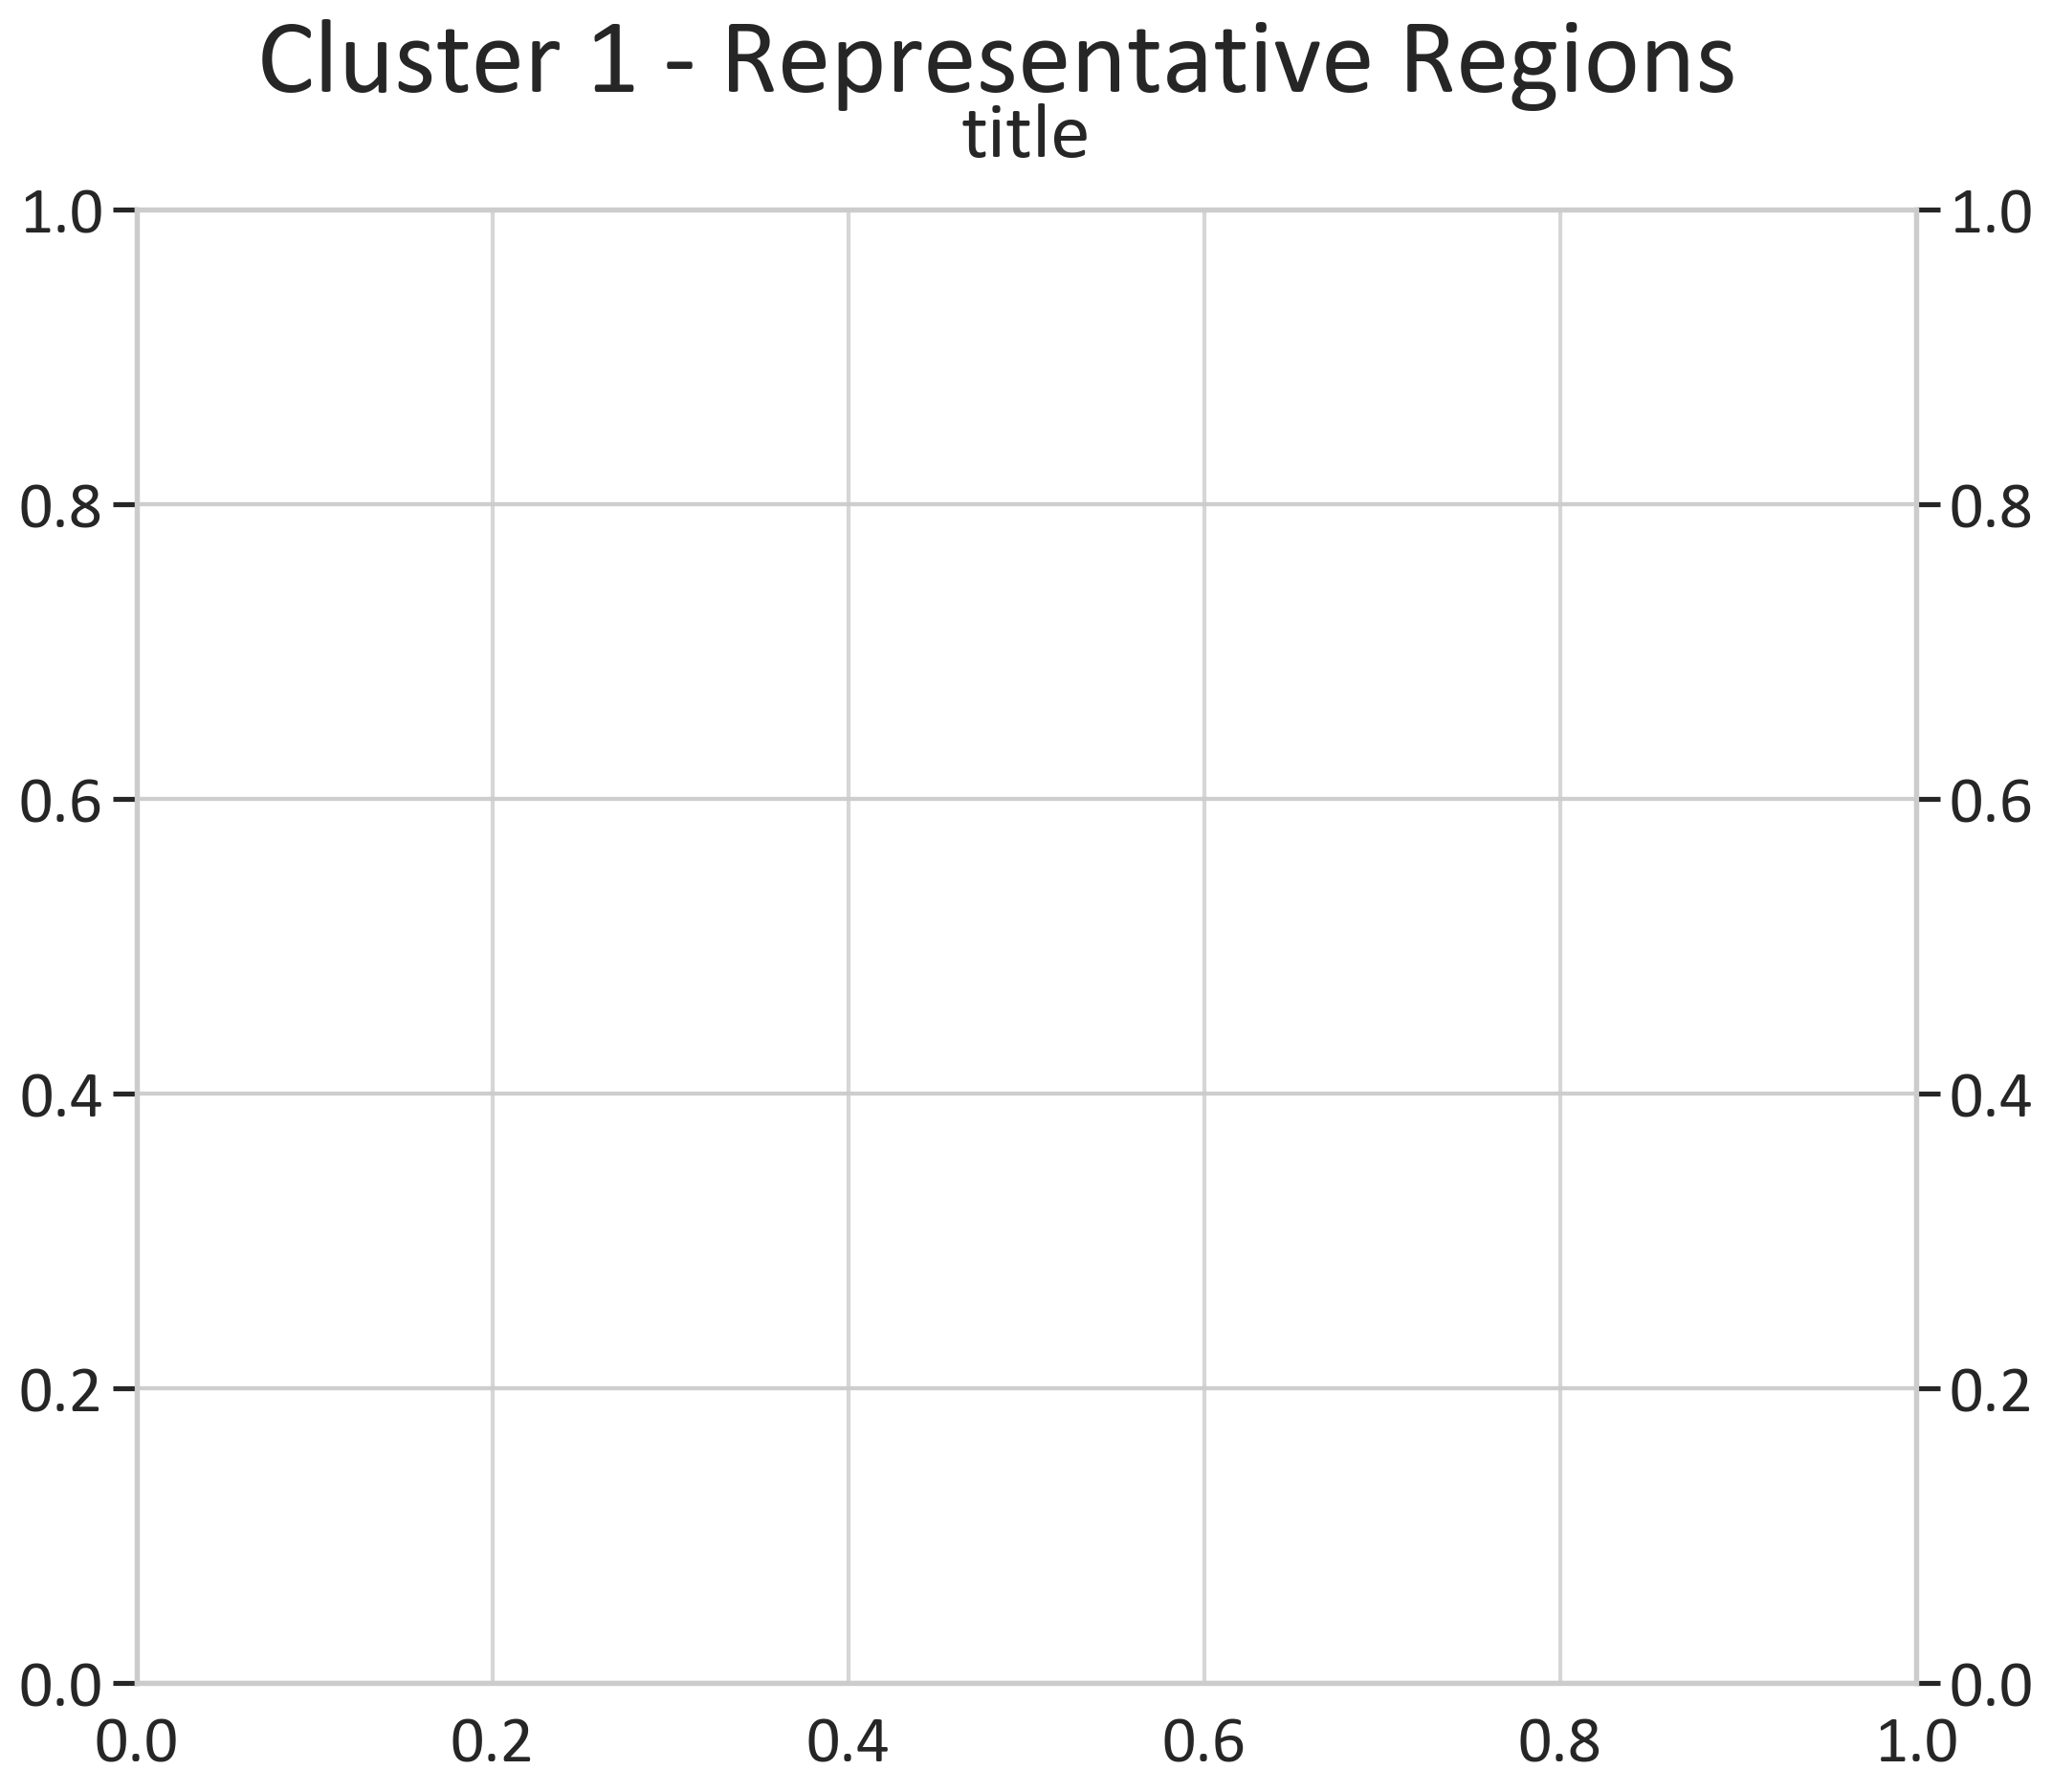

In [ ]:
age_min, age_max = 15, 85
age_col = "age_at_scan"

age_grid = np.linspace(age_min, age_max, 300)

rois = []

rep_ylims = {
    "gm_vol": (200, 4000),
    "adc": (0.75e-3, 1.15e-3),
}

metric_vis = {
    "gm_vol": "GM Volume",
    "adc": "Mean Diffusivity",
}

for cluster in range(1, best_k + 1):
    # get the most representative region for this cluster
    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

    fig, ax1 = plt.subplots(figsize=(12, 10))
    fig.suptitle(f"Cluster {cluster} - Representative Regions", fontsize=40)
    i = clusters.sort_values(f"probability_{cluster}").index[-1]
    rois.append(i)
    ax2 = ax1.twinx()  # create a twin axis for the second metric
    lines = []
    labels = []
    for metric, ax, title, color in zip(
        ["gm_vol", "adc"], [ax1, ax2], ["GM Volume", "Mean Diffusivity"], [COL_RAW, COL_WEIGHTED]
    ):
        ax.set_title("title", fontsize=30, pad=20)
        metric_col = "volume" if metric == "gm_vol" else distribution_metric
        d = all_data[metric]
        d = d[d[region_col] == parcels.loc[i, region_col]].copy()
        # remove outliers
        is_outlier = (d[metric_col] > d[metric_col].quantile(0.99)) | (
            d[metric_col] < d[metric_col].quantile(0.01)
        )
        d = d[~is_outlier].copy()
        print(metric, d[metric_col].min(), d[metric_col].max())
        lm = regional_results[metric]["lin_w"].loc[i, "model"]
        qm = regional_results[metric]["quad_w"].loc[i, "model"]

        # build prediction grid for this metric
        mean_age = mean_age_by_metric[metric]
        grid_df = pd.DataFrame({
            "age_c": age_grid - mean_age,
            "age_c2": (age_grid - mean_age) ** 2,
        })

        # add any covariates present in models (use median/mode)
        covs = [
            v
            for v in qm.model.exog_names
            if v not in ["Intercept", "age_c", "age_c2"]
        ]
        for c in covs:
            if pd.api.types.is_numeric_dtype(d[c]):
                grid_df[c] = d[c].median()
            else:
                grid_df[c] = d[c].mode()[0]

        # 4. Get predictions & CI
        tag = "Quadratic"
        model = qm  # use the quadratic model for both metrics
        pr = model.get_prediction(grid_df)
        ci = pr.conf_int(alpha=0.05)
        grid_df[f"{tag}_fit"] = pr.predicted_mean
        grid_df[f"{tag}_lo"] = ci[:, 0]
        grid_df[f"{tag}_hi"] = ci[:, 1]

        # 5. Plot
        ax.clear()  # reuse the same axes handle

        # Background scatter (down-sample for speed / clarity)
        sizes = np.clip(d["weight"] * 10, 0, 100)
        sns.scatterplot(
            data=d,
            x=age_col,
            y=metric_col,
            alpha=0.3,
            s=sizes,
            edgecolor="none",
            ax=ax,
            legend=False,
            color=color,
        )

        label = f"{metric_vis[metric]} - $R^2$ = {model.rsquared:.2f}"
        lines += ax.plot(age_grid, grid_df[f"{tag}_fit"], label=label, lw=2, color=color)
        labels += [label]
        ax.fill_between(
            age_grid,
            grid_df[f"{tag}_lo"],
            grid_df[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )

        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
        if metric == "gm_vol":
            ylabel = "GM Volume (mm^3)"
        else:
            ylabel = "MD (mm^2/s)"
        ax.set_xlabel("Age (years)", fontsize=35)
        ax.set_xlim((age_min, age_max))
        ax.set_ylabel(ylabel, fontsize=35, color=color)
        ax.yaxis.set_label_position("left" if metric == "gm_vol" else "right")
        ax.yaxis.tick_left() if metric == "gm_vol" else ax.yaxis.tick_right()
        ax.tick_params(axis="y", which="major", labelsize=20, color=color, labelcolor=color)

        # change tick size
        ax.tick_params(axis="both", which="major", labelsize=35)

    plt.grid(True)
    plt.legend(lines, labels, frameon=False, fontsize=35, loc="upper left")


gm_vol 2111.2625224992307 4104.094532424455


KeyError: 'C(sex)[T.1]'

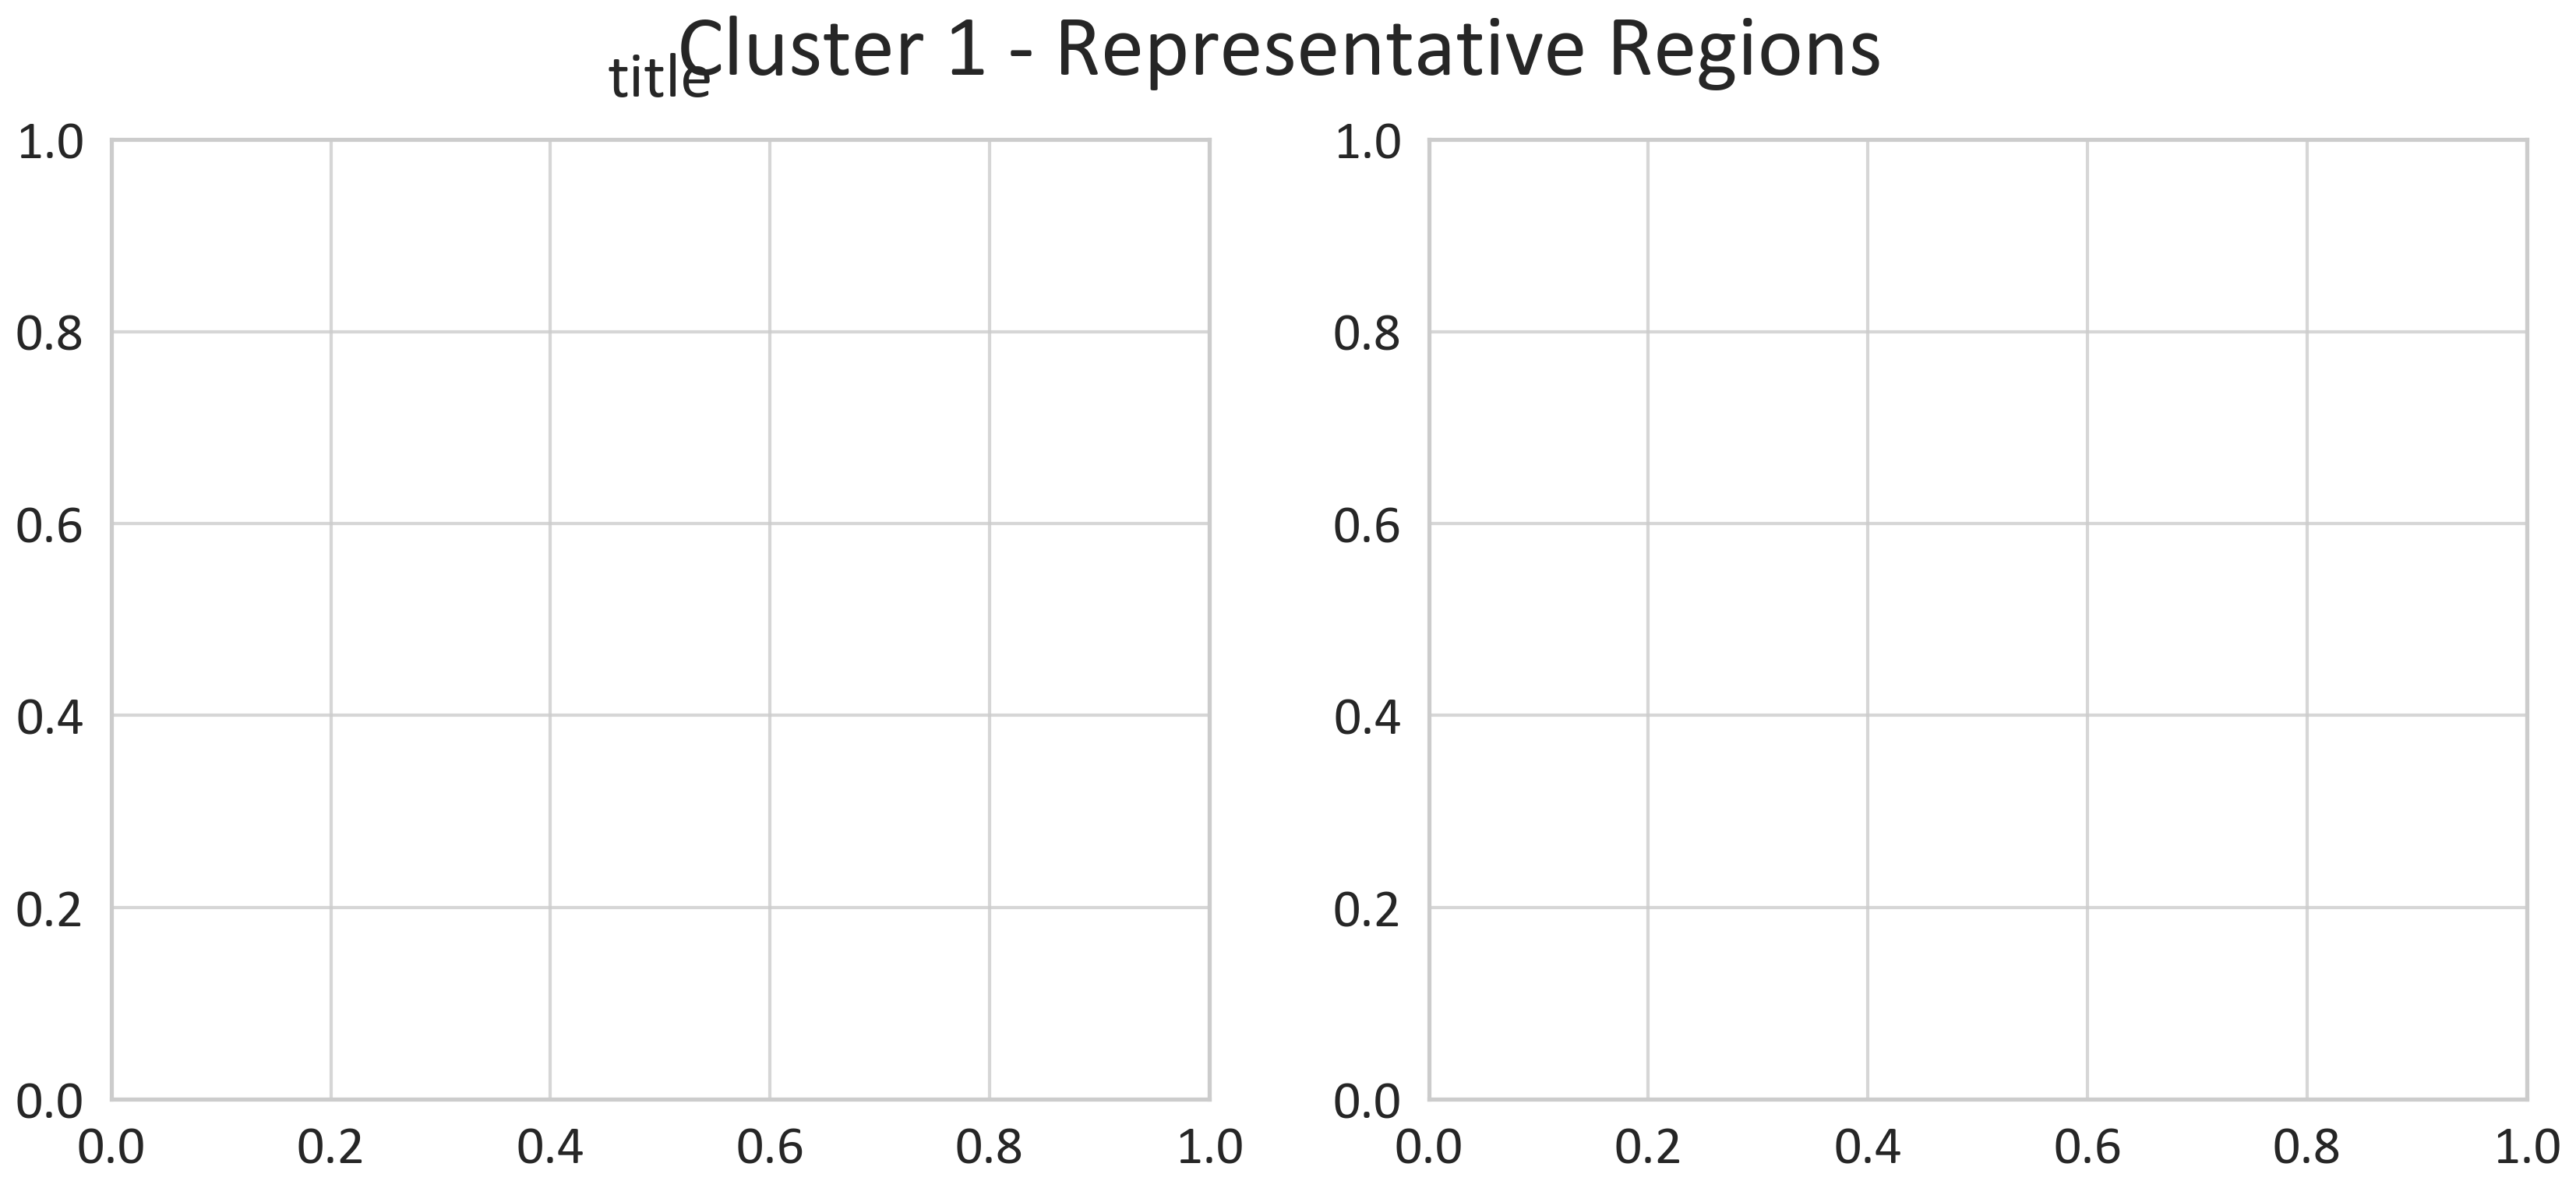

In [ ]:
age_min, age_max = 15, 85
age_col = "age_at_scan"

age_grid = np.linspace(age_min, age_max, 300)

rois = []

rep_ylims = {
    "gm_vol": (200, 4000),
    "adc": (0.75e-3, 1.15e-3),
}

for cluster in range(1, best_k + 1):
    # get the most representative region for this cluster
    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"Cluster {cluster} - Representative Regions", fontsize=40)
    i = clusters.sort_values(f"probability_{cluster}").index[-1]
    rois.append(i)
    for metric, ax, title in zip(["gm_vol", "adc"], axes, ["GM Volume", "Mean Diffusivity"]):
        ax.set_title("title", fontsize=30, pad=20)
        metric_col = "volume" if metric == "gm_vol" else distribution_metric
        d = all_data[metric]
        d = d[d[region_col] == parcels.loc[i, region_col]].copy()
        # remove outliers
        is_outlier = (d[metric_col] > d[metric_col].quantile(0.99)) | (
            d[metric_col] < d[metric_col].quantile(0.01)
        )
        d = d[~is_outlier].copy()
        print(metric, d[metric_col].min(), d[metric_col].max())
        lm = regional_results[metric]["lin_w"].loc[i, "model"]
        qm = regional_results[metric]["quad_w"].loc[i, "model"]

        # build prediction grid for this metric
        mean_age = mean_age_by_metric[metric]
        grid_df = pd.DataFrame({
            "age_c": age_grid - mean_age,
            "age_c2": (age_grid - mean_age) ** 2,
        })

        # add any covariates present in models (use median/mode)
        covs = [
            v
            for v in qm.model.exog_names
            if v not in ["Intercept", "age_c", "age_c2"]
        ]
        for c in covs:
            if pd.api.types.is_numeric_dtype(d[c]):
                grid_df[c] = d[c].median()
            else:
                grid_df[c] = d[c].mode()[0]

        # 4. Get predictions & CI
        for tag, model in [("Linear", lm), ("Quadratic", qm)]:
            pr = model.get_prediction(grid_df)
            ci = pr.conf_int(alpha=0.05)
            grid_df[f"{tag}_fit"] = pr.predicted_mean
            grid_df[f"{tag}_lo"] = ci[:, 0]
            grid_df[f"{tag}_hi"] = ci[:, 1]

        # 5. Plot
        ax.clear()  # reuse the same axes handle

        # Background scatter (down-sample for speed / clarity)
        sizes = np.clip(d["weight"] * 10, 0, 100)
        sns.scatterplot(
            data=d,
            x=age_col,
            y=metric_col,
            alpha=0.7,
            s=sizes,
            edgecolor="none",
            ax=ax,
            legend=False,
            color=COL_REF,
        )

        # Fit lines & ribbons
        for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
            label = f"{tag} - $R^2$ = {model.rsquared:.2f}"
            ax.plot(age_grid, grid_df[f"{tag}_fit"], label=label, lw=2, color=color)
            ax.fill_between(
                age_grid,
                grid_df[f"{tag}_lo"],
                grid_df[f"{tag}_hi"],
                color=color,
                alpha=0.3,
            )

        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
        if metric == "gm_vol":
            ylabel = "GM Volume (mm^3)"
        else:
            ylabel = "MD (mm^2/s)"

        ax.set(
            xlabel="Age (years)",
            ylabel=ylabel,
            xlim=(age_min, age_max),
        )

        # change tick size
        ax.tick_params(axis="both", which="major", labelsize=35)
        ax.legend(frameon=False, fontsize=35, loc="upper left")

    plt.tight_layout()


In [ ]:
d[metric_col].max()

np.float64(0.0011626573651275)

In [ ]:
parcels.loc[rois]

,index,name,base_name,Label Name,network,component,hemisphere
177,178,7Networks_LH_Default_PFC_13,7networks_lh_default_pfc,7Networks_LH_Default_PFC,default,prefrontal cortex,L
230,231,7Networks_RH_SomMot_1,7networks_rh_sommot,7Networks_RH_SomMot,somatomotor,somatomotor,R
432,433,HIP-body-lh,HIP-body,Hippocampus body,subcortex,Hippocampus body,L
123,124,7Networks_LH_Limbic_TempPole_6,7networks_lh_limbic_temppole,7Networks_LH_Limbic_TempPole,limbic,temporal pole,L
214,215,7Networks_RH_Vis_15,7networks_rh_vis,7Networks_RH_Vis,visual,visual,R
